# CELL 1: Install Ollama + Pull Model (idempotent)

In [ ]:
# @title
import os, time, shutil

# Step 1: Install zstd if needed
if not shutil.which("zstd"):
    print("📦 Installing zstd...")
    !sudo apt-get install -y -qq zstd > /dev/null 2>&1
else:
    print("✅ zstd already installed")

# Step 2: Install Ollama if needed
if not shutil.which("ollama"):
    print("📦 Installing Ollama...")
    !curl -fsSL https://ollama.com/install.sh | sh
else:
    print("✅ Ollama already installed")

# Step 3: Stop systemd service (Colab can't use it)
!sudo systemctl stop ollama 2>/dev/null; true

# Step 4: Set GPU environment
os.environ['LD_LIBRARY_PATH'] = '/usr/lib64-nvidia'
os.environ['PATH'] += ':/usr/local/cuda/bin'

# Step 5: Start server if not already running
import requests
server_ok = False
try:
    r = requests.get("http://localhost:11434/api/tags", timeout=3)
    if r.status_code == 200:
        server_ok = True
        print("✅ Ollama server already running")
except:
    pass

if not server_ok:
    print("🚀 Starting Ollama server...")
    os.system("pkill -f 'ollama serve' 2>/dev/null; true")
    time.sleep(1)
    os.system("nohup ollama serve > /tmp/ollama.log 2>&1 &")
    time.sleep(5)
    for attempt in range(15):
        try:
            r = requests.get("http://localhost:11434/api/tags", timeout=3)
            if r.status_code == 200:
                print("✅ Ollama server started!")
                server_ok = True
                break
        except:
            pass
        time.sleep(2)
    if not server_ok:
        print("❌ Server failed to start. Logs:")
        !cat /tmp/ollama.log | tail -20

# Step 6: Pull model if not already downloaded
if server_ok:
    r = requests.get("http://localhost:11434/api/tags", timeout=5)
    models = [m["name"] for m in r.json().get("models", [])]
    if any("qwen2.5:7b" in m for m in models):
        print("✅ qwen2.5:7b already downloaded")
    else:
        print("📥 Pulling qwen2.5:7b (3-5 minutes)...")
        !ollama pull qwen2.5:7b
        print("✅ Model ready!")
    !ollama list

✅ zstd already installed
✅ Ollama already installed
🚀 Starting Ollama server...
✅ Ollama server started!
✅ qwen2.5:7b already downloaded
NAME          ID              SIZE      MODIFIED       
qwen2.5:7b    845dbda0ea48    4.7 GB    56 minutes ago    


# CELL 2: Project Structure + Aquatic Environment

In [ ]:
# @title
# CELL 2: Project Structure + Aquatic Environment
import os

BASE = "/content/AquaLLM"

# Create directories
for d in [f"{BASE}/core", f"{BASE}/agent", f"{BASE}/logs", f"{BASE}/plots"]:
    os.makedirs(d, exist_ok=True)

# Create __init__.py files
for pkg in ["core", "agent"]:
    init_path = f"{BASE}/{pkg}/__init__.py"
    if not os.path.exists(init_path):
        with open(init_path, "w") as f:
            f.write("")

# ═══════════════════════════════════════════════════════════════
# FILE 1: entities.py
# ═══════════════════════════════════════════════════════════════

ENTITIES_PY = r'''#!/usr/bin/env python3
"""
entities.py -- Simulation entity dataclasses (3D).
PondGenotype is a pure data container -- EA operations live in ea.py.
"""

from dataclasses import dataclass
from typing import Tuple

from constants import (
    FOOD_PRICE, PROBIOTIC_PRICE, OXYGEN_PRICE,
    VELOCITY_HEALTH_THRESHOLD, VELOCITY_FULLNESS_THRESHOLD,
    PARASITE_VELOCITY_MULT, FLOOR_HAZARD_HEIGHT,
)


@dataclass
class PondGenotype:
    fish_count: int = 30
    food_interval: int = 6
    food_quantity: int = 3
    food_location: int = 0
    probiotic_interval: int = 24
    probiotic_quantity: int = 2
    probiotic_location: int = 0
    oxygen_interval: int = 8
    oxygen_duration: int = 2
    oxygen_location: int = 0

    def total_cost(self, runtime: int) -> float:
        fc = (runtime / self.food_interval) * self.food_quantity * FOOD_PRICE
        pc = (runtime / self.probiotic_interval) * self.probiotic_quantity * PROBIOTIC_PRICE
        oc = (runtime / self.oxygen_interval) * self.oxygen_duration * OXYGEN_PRICE
        return fc + pc + oc

    def per_cycle_cost(self) -> float:
        return (self.food_quantity * FOOD_PRICE +
                self.probiotic_quantity * PROBIOTIC_PRICE +
                self.oxygen_duration * OXYGEN_PRICE)

    def to_dict(self) -> dict:
        return {k: getattr(self, k) for k in [
            'fish_count',
            'food_interval', 'food_quantity', 'food_location',
            'probiotic_interval', 'probiotic_quantity', 'probiotic_location',
            'oxygen_interval', 'oxygen_duration', 'oxygen_location']}


@dataclass
class Obstacle:
    x: float; y: float; z: float; w: float; h: float; d: float

    def contains(self, px, py, pz) -> bool:
        return (self.x <= px <= self.x + self.w and
                self.y <= py <= self.y + self.h and
                self.z <= pz <= self.z + self.d)

    def nearest_surface(self, px, py, pz) -> Tuple[float, float, float]:
        cx = max(self.x, min(px, self.x + self.w))
        cy = max(self.y, min(py, self.y + self.h))
        cz = max(self.z, min(pz, self.z + self.d))
        return cx, cy, cz

    def center(self) -> Tuple[float, float, float]:
        return self.x + self.w / 2, self.y + self.h / 2, self.z + self.d / 2

    def top_z(self) -> float:
        return self.z

    def xy_contains(self, px, py) -> bool:
        return self.x <= px <= self.x + self.w and self.y <= py <= self.y + self.h


@dataclass
class DynObj:
    x: float; y: float; z: float; kind: str; value: float = 5.0
    age: int = 0; max_age: int = 30
    vx: float = 0.0; vy: float = 0.0; vz: float = 0.0
    alive: bool = True
    on_floor: bool = False
    float_timer: int = 0
    obj_id: int = -1


@dataclass
class Hazard:
    x: float; y: float; z: float; radius: float; kind: str
    age: int = 0; max_age: int = 50; alive: bool = True
    vx: float = 0.0; vy: float = 0.0; vz: float = 0.0
    is_floor: bool = False
    follow_dead_fish: bool = False
    follow_id: int = -1

    def contains(self, px, py, pz) -> bool:
        if self.is_floor:
            if pz < self.z - FLOOR_HAZARD_HEIGHT:
                return False
            return (px - self.x) ** 2 + (py - self.y) ** 2 <= self.radius ** 2
        return ((px - self.x) ** 2 + (py - self.y) ** 2 +
                (pz - self.z) ** 2) <= self.radius ** 2


@dataclass
class Fish:
    fid: int = 0
    x: float = 0.0; y: float = 0.0; z: float = 0.0
    vx: float = 0.0; vy: float = 0.0; vz: float = 0.0
    mouth_size: float = 5.0; body_size: float = 6.0
    health: float = 100.0; max_health: float = 100.0
    fullness: float = 60.0; max_fullness: float = 60.0
    immunity: float = 80.0; max_immunity: float = 80.0
    oxygen: float = 90.0; max_oxygen: float = 90.0
    base_velocity: float = 2.0
    is_infected: bool = False; has_parasite: bool = False
    alive: bool = True; fecal_timer: int = 0

    def eff_vel(self) -> float:
        v = self.base_velocity
        if self.health <= self.max_health * VELOCITY_HEALTH_THRESHOLD: v *= 0.5
        if self.fullness <= self.max_fullness * VELOCITY_FULLNESS_THRESHOLD: v *= 0.5
        if self.has_parasite: v *= PARASITE_VELOCITY_MULT
        return v

    def norm_stats(self) -> float:
        h_n = max(0, self.health) / self.max_health
        fu_n = max(0, self.fullness) / self.max_fullness
        im_n = max(0, self.immunity) / self.max_immunity
        vl_n = min(1.0, self.eff_vel() / (self.base_velocity + 1e-9))
        return (h_n + fu_n + im_n + vl_n) / 4.0

    def snapshot(self) -> dict:
        return {
            'id': self.fid,
            'x': round(self.x, 1), 'y': round(self.y, 1), 'z': round(self.z, 1),
            'health': round(self.health, 1), 'max_health': round(self.max_health, 1),
            'fullness': round(self.fullness, 1), 'max_fullness': round(self.max_fullness, 1),
            'immunity': round(self.immunity, 1), 'max_immunity': round(self.max_immunity, 1),
            'oxygen': round(self.oxygen, 1), 'max_oxygen': round(self.max_oxygen, 1),
            'alive': self.alive,
            'is_infected': self.is_infected, 'has_parasite': self.has_parasite,
            'body_size': round(self.body_size, 1), 'mouth_size': round(self.mouth_size, 1),
            'base_velocity': round(self.base_velocity, 2),
            'vx': round(self.vx, 2), 'vy': round(self.vy, 2), 'vz': round(self.vz, 2),
        }
'''

# ═══════════════════════════════════════════════════════════════
# FILE 2: helpers.py
# ═══════════════════════════════════════════════════════════════

HELPERS_PY = r'''#!/usr/bin/env python3
"""
helpers.py -- Pure utility functions and fish factory (3D).
"""

import math
import random

from constants import (
    POND_WIDTH, POND_HEIGHT, POND_DEPTH, DropLocation,
    MOUTH_SIZE_RANGE, BODY_SIZE_RANGE,
    HEALTH_RANGE, FULLNESS_RANGE, IMMUNITY_RANGE, OXYGEN_RANGE,
    VELOCITY_RANGE,
)
from entities import Fish


def _dist(x1, y1, z1, x2, y2, z2):
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2 + (z1 - z2) ** 2)


def _clamp(v, lo, hi):
    return max(lo, min(hi, v))


def _norm(vx, vy, vz):
    m = math.sqrt(vx * vx + vy * vy + vz * vz)
    return (vx / m, vy / m, vz / m) if m > 1e-8 else (0.0, 0.0, 0.0)


def _drop_pos(loc: int):
    """Return (x, y) for a drop location. Z is handled by caller."""
    W, H = POND_WIDTH, POND_HEIGHT
    mx, my = W * 0.15, H * 0.15
    jx = random.uniform(-mx * 0.3, mx * 0.3)
    jy = random.uniform(-my * 0.3, my * 0.3)

    if loc == DropLocation.CENTER:
        return W / 2 + jx, H / 2 + jy
    elif loc == DropLocation.TOP_LEFT:
        return mx + jx, my + jy
    elif loc == DropLocation.TOP_RIGHT:
        return W - mx + jx, my + jy
    elif loc == DropLocation.BOT_LEFT:
        return mx + jx, H - my + jy
    elif loc == DropLocation.BOT_RIGHT:
        return W - mx + jx, H - my + jy
    elif loc == DropLocation.TOP_CENTER:
        return W / 2 + jx, my + jy
    elif loc == DropLocation.BOT_CENTER:
        return W / 2 + jx, H - my + jy
    elif loc == DropLocation.LEFT_CENTER:
        return mx + jx, H / 2 + jy
    elif loc == DropLocation.RIGHT_CENTER:
        return W - mx + jx, H / 2 + jy
    else:
        return random.uniform(10, W - 10), random.uniform(5, H - 5)


def _make_fish(fid: int) -> Fish:
    f = Fish(fid=fid)
    f.x = random.uniform(15, POND_WIDTH - 15)
    f.y = random.uniform(10, POND_HEIGHT - 10)
    f.z = random.uniform(5, POND_DEPTH - 5)
    f.mouth_size = random.uniform(*MOUTH_SIZE_RANGE)
    f.body_size = random.uniform(*BODY_SIZE_RANGE)
    f.max_health = random.uniform(*HEALTH_RANGE); f.health = f.max_health
    f.max_fullness = random.uniform(*FULLNESS_RANGE); f.fullness = f.max_fullness * 0.8
    f.max_immunity = random.uniform(*IMMUNITY_RANGE); f.immunity = f.max_immunity
    f.max_oxygen = random.uniform(*OXYGEN_RANGE); f.oxygen = f.max_oxygen
    f.base_velocity = random.uniform(*VELOCITY_RANGE)
    f.vx = random.uniform(-1, 1)
    f.vy = random.uniform(-1, 1)
    f.vz = random.uniform(-0.5, 0.5)
    return f


FISH_DICT_KEYS = [
    'fid', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'mouth_size', 'body_size',
    'health', 'max_health', 'fullness', 'max_fullness',
    'immunity', 'max_immunity', 'oxygen', 'max_oxygen', 'base_velocity',
    'is_infected', 'has_parasite', 'alive', 'fecal_timer']


def _fish_to_dict(f: Fish) -> dict:
    return {s: getattr(f, s) for s in FISH_DICT_KEYS}


def _dict_to_fish(d: dict) -> Fish:
    f = Fish()
    for k, v in d.items():
        if hasattr(f, k):
            setattr(f, k, v)
    return f


class SpatialGrid:
    """3D spatial hash grid for fast neighbor lookups."""

    def __init__(self, cell_size=30.0):
        self.cell_size = cell_size
        self.cells = {}

    def clear(self):
        self.cells.clear()

    def _key(self, x, y, z):
        return (int(x // self.cell_size),
                int(y // self.cell_size),
                int(z // self.cell_size))

    def insert(self, obj):
        k = self._key(obj.x, obj.y, obj.z)
        if k not in self.cells:
            self.cells[k] = []
        self.cells[k].append(obj)

    def insert_all(self, objects):
        self.clear()
        for obj in objects:
            self.insert(obj)

    def get_nearby(self, x, y, z, radius):
        cs = self.cell_size
        r_cells = int(radius // cs) + 1
        cx, cy, cz = int(x // cs), int(y // cs), int(z // cs)
        r2 = radius * radius
        for dx in range(-r_cells, r_cells + 1):
            for dy in range(-r_cells, r_cells + 1):
                for dz in range(-r_cells, r_cells + 1):
                    cell = self.cells.get((cx + dx, cy + dy, cz + dz))
                    if cell:
                        for obj in cell:
                            ddx = obj.x - x
                            ddy = obj.y - y
                            ddz = obj.z - z
                            if ddx * ddx + ddy * ddy + ddz * ddz <= r2:
                                yield obj
'''

# ═══════════════════════════════════════════════════════════════
# FILE 3: physics.py
# ═══════════════════════════════════════════════════════════════

PHYSICS_PY = r'''#!/usr/bin/env python3
"""
physics.py -- Environment physics: object movement, hazard updates,
              pollutant transformation, floor stacking.
"""

import random, math

from constants import (
    POND_WIDTH, POND_HEIGHT, POND_DEPTH,
    OXYGEN_BUBBLE_SPEED, NH3_BUBBLE_SPEED, NH3_AREA_RADIUS_RANGE,
    NH3_EXPIRE_TIMESTEPS, DISEASE_AREA_DECAY, PARASITE_AREA_DECAY,
    POLLUTANT_TO_HAZARD_TIMESTEPS, DISEASE_AREA_RADIUS_DECAY,
    POLLUTANT_TO_NH3_CHANCE, POLLUTANT_TO_DISEASE_CHANCE,
    POLLUTANT_TO_PARASITE_CHANCE, POLLUTANT_TO_BOTH_CHANCE,
    POLLUTANT_TO_PLANT_CHANCE, POLLUTANT_TO_OBSTACLE_CHANCE,
    POLLUTANT_RADIUS_SCALE, DEAD_FISH_POLLUTANT_MULT,
    POLLUTANT_OBSTACLE_AREA_RANGE,
    OBSTACLE_MAX_WIDTH, OBSTACLE_MAX_HEIGHT, OBSTACLE_MAX_DEPTH,
    SINK_SPEED, SINK_SPEED_HEAVY,
    DEAD_FISH_NH3_RADIUS, DEAD_FISH_FLOAT_SPEED,
    FECAL_SINK_SPEED,
    STACK_RADIUS,
)
from entities import Obstacle, DynObj, Hazard
from helpers import _dist, _clamp

_WALL = 2.0
_FLOOR_Z = POND_DEPTH - _WALL


def upd_objs(sim):
    """Move/age all dynamic objects. Handles sinking, drifting, expiry, pollutant conversion."""
    keep = []
    for o in sim.objs:
        if o.kind == 'oxygen':
            o.age += 1
            o.x += o.vx; o.y += o.vy; o.z += o.vz
            if o.x < _WALL or o.x > POND_WIDTH-_WALL: o.vx *= -1
            if o.y < _WALL or o.y > POND_HEIGHT-_WALL: o.vy *= -1
            if o.z < _WALL or o.z > POND_DEPTH-_WALL: o.vz *= -1
            o.x, o.y, o.z = sim._cp(o.x, o.y, o.z)
            if any(h.contains(o.x, o.y, o.z) and h.kind == 'nh3' and h.alive for h in sim.hazards):
                continue
            keep.append(o); continue

        if o.kind == 'plant':
            keep.append(o); continue

        if o.kind in ('food', 'probiotic'):
            rest_z = sim._resting_z(o.x, o.y)
            if not o.on_floor:
                o.x += o.vx; o.y += o.vy; o.z += o.vz
                if o.x < _WALL or o.x > POND_WIDTH-_WALL: o.vx *= -1
                if o.y < _WALL or o.y > POND_HEIGHT-_WALL: o.vy *= -1
                o.x = _clamp(o.x, _WALL, POND_WIDTH-_WALL)
                o.y = _clamp(o.y, _WALL, POND_HEIGHT-_WALL)
                o.z = max(o.z, _WALL)
                if o.z >= rest_z:
                    o.z = rest_z
                    o.on_floor = True
                    o.vx = 0.0; o.vy = 0.0; o.vz = 0.0
            if o.on_floor: o.age += 1

            if o.age >= o.max_age and o.alive:
                if o.value > 0:
                    keep.append(DynObj(o.x, o.y, o.z, 'pollutant', o.value,
                                       max_age=POLLUTANT_TO_HAZARD_TIMESTEPS, on_floor=True))
                continue
            if o.alive: keep.append(o)
            continue

        if o.kind == 'dead_fish':
            rest_z = sim._resting_z(o.x, o.y)

            if o.float_timer > 0:
                o.z = max(_WALL, o.z - DEAD_FISH_FLOAT_SPEED)
                if o.z <= _WALL:
                    o.z = _WALL
                o.float_timer -= 1
            elif o.z < rest_z:
                o.z = min(o.z + SINK_SPEED_HEAVY, rest_z)

            # Follower NH3 tracks this specific body via matching ID
            for h in sim.hazards:
                if h.follow_dead_fish and h.kind == 'nh3' and h.follow_id == o.obj_id:
                    h.x, h.y, h.z = o.x, o.y, o.z

            o.on_floor = o.z >= rest_z - 0.1
            if o.on_floor: o.age += 1

            if o.age >= o.max_age and o.alive:
                # Kill the linked follower NH3
                for h in sim.hazards:
                    if h.follow_dead_fish and h.kind == 'nh3' and h.follow_id == o.obj_id:
                        h.alive = False
                if o.value > 0:
                    pv = o.value * DEAD_FISH_POLLUTANT_MULT
                    if not any(h.contains(o.x, o.y, o.z) and h.kind == 'nh3' and h.alive for h in sim.hazards):
                        keep.append(DynObj(o.x, o.y, o.z, 'pollutant', pv,
                                           max_age=POLLUTANT_TO_HAZARD_TIMESTEPS, on_floor=True))
                continue
            if o.alive: keep.append(o)
            continue

        if o.kind == 'fecal':
            rest_z = sim._resting_z(o.x, o.y)
            if not o.on_floor:
                o.z = min(o.z + FECAL_SINK_SPEED, rest_z)
                if o.z >= rest_z:
                    o.z = rest_z
                    o.on_floor = True

            if o.on_floor: o.age += 1

            if o.age >= o.max_age and o.alive:
                if o.value > 0:
                    if not any(h.contains(o.x, o.y, o.z) and h.kind == 'nh3' and h.alive for h in sim.hazards):
                        keep.append(DynObj(o.x, o.y, o.z, 'pollutant', o.value,
                                           max_age=POLLUTANT_TO_HAZARD_TIMESTEPS, on_floor=True))
                continue
            if o.alive: keep.append(o)
            continue

        # pollutant and other kinds
        o.on_floor = o.z >= sim._resting_z(o.x, o.y) - 0.1
        if o.on_floor: o.age += 1

        if o.age >= o.max_age and o.alive:
            if o.kind == 'pollutant':
                transform_pollutant(sim, o)
                continue
        if o.alive: keep.append(o)
    sim.objs = keep


def transform_pollutant(sim, o):
    """Convert an expired pollutant into a hazard, plant, obstacle, or nothing."""
    r = o.value * POLLUTANT_RADIUS_SCALE
    roll = random.random()
    cumul = 0.0
    cumul += POLLUTANT_TO_NH3_CHANCE
    if roll < cumul:
        sim.hazards.append(Hazard(o.x, o.y, o.z, r, 'nh3', max_age=NH3_EXPIRE_TIMESTEPS,
            vx=random.uniform(-NH3_BUBBLE_SPEED, NH3_BUBBLE_SPEED),
            vy=random.uniform(-NH3_BUBBLE_SPEED, NH3_BUBBLE_SPEED),
            vz=random.uniform(-NH3_BUBBLE_SPEED*0.5, NH3_BUBBLE_SPEED*0.5)))
        return
    cumul += POLLUTANT_TO_DISEASE_CHANCE
    if roll < cumul:
        sim.hazards.append(Hazard(o.x, o.y, _FLOOR_Z, r, 'disease', max_age=DISEASE_AREA_DECAY, is_floor=True))
        return
    cumul += POLLUTANT_TO_PARASITE_CHANCE
    if roll < cumul:
        sim.hazards.append(Hazard(o.x, o.y, _FLOOR_Z, r, 'parasite', max_age=PARASITE_AREA_DECAY, is_floor=True))
        return
    cumul += POLLUTANT_TO_BOTH_CHANCE
    if roll < cumul:
        sim.hazards.append(Hazard(o.x, o.y, _FLOOR_Z, r, 'disease', max_age=DISEASE_AREA_DECAY, is_floor=True))
        sim.hazards.append(Hazard(o.x, o.y, _FLOOR_Z, r*0.8, 'parasite', max_age=PARASITE_AREA_DECAY, is_floor=True))
        return
    cumul += POLLUTANT_TO_PLANT_CHANCE
    if roll < cumul:
        sim.objs.append(DynObj(o.x, o.y, _FLOOR_Z, 'plant', 0, max_age=999999))
        return
    cumul += POLLUTANT_TO_OBSTACLE_CHANCE
    if roll < cumul:
        area = random.uniform(*POLLUTANT_OBSTACLE_AREA_RANGE)
        aspect = random.uniform(0.5, 2.0)
        w = math.sqrt(area * aspect)
        h = area / w if w > 0 else math.sqrt(area)
        w = min(w, OBSTACLE_MAX_WIDTH); h = min(h, OBSTACLE_MAX_HEIGHT)
        d = random.uniform(2, 5); d = min(d, OBSTACLE_MAX_DEPTH)
        ox = _clamp(o.x - w/2, _WALL, POND_WIDTH - _WALL - w)
        oy = _clamp(o.y - h/2, _WALL, POND_HEIGHT - _WALL - h)
        oz = _FLOOR_Z - d
        sim.obstacles.append(Obstacle(ox, oy, oz, w, h, d))
        return
    # Remaining POLLUTANT_TO_NOTHING_CHANCE: harmless decomposition


def upd_haz(sim):
    """Move/age all hazards. Expired NH3 becomes pollutant."""
    keep = []
    for h in sim.hazards:
        if not h.alive:
            continue
        h.age += 1
        if h.kind == 'nh3' and not h.follow_dead_fish:
            h.x += h.vx; h.y += h.vy; h.z += h.vz
            if h.x < 5 or h.x > POND_WIDTH-5: h.vx *= -1
            if h.y < 3 or h.y > POND_HEIGHT-3: h.vy *= -1
            if h.z < 3 or h.z > POND_DEPTH-3: h.vz *= -1
            h.x = _clamp(h.x, 5, POND_WIDTH-5)
            h.y = _clamp(h.y, 3, POND_HEIGHT-3)
            h.z = _clamp(h.z, 3, POND_DEPTH-3)
        if h.age >= h.max_age:
            if h.kind == 'nh3':
                sim.objs.append(DynObj(h.x, h.y, _FLOOR_Z, 'pollutant', h.radius*0.5,
                                        max_age=POLLUTANT_TO_HAZARD_TIMESTEPS, on_floor=True))
            continue
        if h.kind in ('disease', 'parasite'):
            h.radius = max(0.5, h.radius * DISEASE_AREA_RADIUS_DECAY)
        keep.append(h)
    sim.hazards = keep


def stack_floor_objs(sim):
    """Merge stackable objects (food, probiotic, fecal) on the floor within STACK_RADIUS."""
    floor_objs = [o for o in sim.objs if o.alive and o.on_floor and o.kind in ('food', 'probiotic', 'fecal')]
    if not floor_objs:
        return
    by_kind = {}
    for o in floor_objs:
        by_kind.setdefault(o.kind, []).append(o)

    for kind, group in by_kind.items():
        for i in range(len(group)):
            a = group[i]
            if not a.alive:
                continue
            for j in range(i + 1, len(group)):
                b = group[j]
                if not b.alive:
                    continue
                if _dist(a.x, a.y, a.z, b.x, b.y, b.z) < STACK_RADIUS:
                    a.value += b.value
                    b.alive = False
'''

# ═══════════════════════════════════════════════════════════════
# FILE 4: behavior.py
# ═══════════════════════════════════════════════════════════════

BEHAVIOR_PY = r'''#!/usr/bin/env python3
"""
behavior.py -- Fish behavior: PSO movement, eating, decay, cannibalism,
               fecal production, death.
"""

import random, math

from constants import (
    POND_WIDTH, POND_HEIGHT, POND_DEPTH, BODY_SIZE_RANGE,
    OXYGEN_DECAY, OXYGEN_DECAY_NH3_MULT, OXYGEN_PASSIVE_REGEN,
    FULLNESS_DECAY, FULLNESS_COST_MOVE,
    HEALTH_DECAY_NO_FULLNESS, HEALTH_DECAY_INFECTED, HEALTH_DECAY_PARASITE,
    HEALTH_DECAY_IN_NH3, HEALTH_REGEN, DISEASE_SELF_CURE_CHANCE,
    IMMUNITY_DECAY_IN_DISEASE, IMMUNITY_DECAY_IN_NH3, IMMUNITY_REGEN,
    PARASITE_CONTACT_CHANCE,
    PARASITE_FULLNESS_EFFICIENCY, PARASITE_EXTRA_FULLNESS_DRAIN,
    FOOD_FULLNESS_GAIN, PROBIOTIC_IMMUNITY_GAIN, OXYGEN_BUBBLE_GAIN,
    FISH_EAT_RANGE, INFECTED_FISH_DISEASE_RADIUS_MULT,
    SENSITIVE_DISTANCE, SOCIAL_DISTANCE, SELFISH_DISTANCE,
    PSO_INERTIA, PSO_FOOD_WEIGHT, PSO_FOOD_URGENT_MULT,
    PSO_FOOD_URGENT_THRESHOLD,
    PSO_PROBIOTIC_WEIGHT,
    PSO_OXYGEN_WEIGHT, PSO_OXYGEN_CRITICAL_MULT,
    PSO_OXYGEN_THRESHOLD, PSO_OXYGEN_CRITICAL_THRESHOLD,
    PSO_SOCIAL_WEIGHT, PSO_SELFISH_WEIGHT,
    PSO_NH3_WEIGHT, PSO_NH3_HUNGRY_OVERRIDE,
    PSO_DISEASE_WEIGHT, PSO_PARASITE_WEIGHT,
    PSO_RUN_WEIGHT, PSO_OBSTACLE_WEIGHT,
    PSO_SWARM_HUNGRY_WEIGHT, PSO_SWARM_HUNGRY_THRESHOLD,
    CANNIBAL_FULLNESS_THRESHOLD, CANNIBAL_BASE_CHANCE, CANNIBAL_HUNGER_MULT,
    CANNIBAL_FULLNESS_GAIN_MULT, CANNIBAL_COLLISION_RADIUS_MULT,
    FECAL_DROP_INTERVAL, FECAL_BASE_CHANCE, FECAL_VALUE, FECAL_SINK_SPEED,
    FECAL_EXPIRE_TIMESTEPS, MAX_SINKING_FECAL,
    DEAD_FISH_DECAY_TIMESTEPS, DEAD_FISH_NH3_RADIUS,
    DEAD_FISH_FLOAT_CHANCE, DEAD_FISH_FLOAT_DURATION_RANGE,
    DISEASE_AREA_DECAY, PARASITE_AREA_DECAY,
    PARASITE_VELOCITY_MULT,
)
from entities import DynObj, Hazard
from helpers import _dist, _clamp, _norm

_WALL = 2.0
_FLOOR_Z = POND_DEPTH - _WALL


def decay(sim):
    """Apply per-tick stat decay, environmental effects, disease/parasite mechanics."""
    for f in sim.fish:
        if not f.alive: continue

        f.oxygen -= OXYGEN_DECAY
        f.fullness -= FULLNESS_DECAY * (PARASITE_EXTRA_FULLNESS_DRAIN if f.has_parasite else 1.0)

        in_nh3 = any(h.kind == 'nh3' and h.contains(f.x, f.y, f.z) for h in sim.hazards)
        if not in_nh3 and f.oxygen < f.max_oxygen:
            f.oxygen = min(f.max_oxygen, f.oxygen + OXYGEN_PASSIVE_REGEN)

        for h in sim.hazards:
            if h.kind == 'nh3' and h.contains(f.x, f.y, f.z):
                f.oxygen -= OXYGEN_DECAY * OXYGEN_DECAY_NH3_MULT
                f.health -= HEALTH_DECAY_IN_NH3
                f.immunity -= IMMUNITY_DECAY_IN_NH3

        if f.fullness <= 0: f.health -= HEALTH_DECAY_NO_FULLNESS
        if f.is_infected: f.health -= HEALTH_DECAY_INFECTED
        if f.has_parasite and sim.ts % 3 == 0: f.health -= HEALTH_DECAY_PARASITE

        fr = f.fullness / f.max_fullness
        or_ = f.oxygen / f.max_oxygen
        ir = f.immunity / f.max_immunity
        if (not f.is_infected and not f.has_parasite and
                fr >= 0.7 and or_ >= 0.7 and ir > 0.7):
            f.health = min(f.max_health, f.health + HEALTH_REGEN)

        if not f.is_infected and f.immunity < f.max_immunity:
            f.immunity = min(f.max_immunity, f.immunity + IMMUNITY_REGEN)

        if f.is_infected:
            if fr >= 0.8 and or_ >= 0.8 and ir >= 0.9:
                if random.random() < DISEASE_SELF_CURE_CHANCE:
                    f.is_infected = False

        for h in sim.hazards:
            if h.kind == 'disease' and h.contains(f.x, f.y, f.z):
                f.immunity -= IMMUNITY_DECAY_IN_DISEASE
                if f.immunity <= 0: f.is_infected = True; f.immunity = 0
            if h.kind == 'parasite' and h.contains(f.x, f.y, f.z):
                if random.random() < PARASITE_CONTACT_CHANCE: f.has_parasite = True

        f.health = max(0, f.health)
        f.oxygen = max(0, f.oxygen)
        f.fullness = max(0, f.fullness)
        f.immunity = max(0, f.immunity)


def eat(sim):
    """Fish consume nearby food, probiotic, and oxygen objects."""
    sim._obj_grid.insert_all([o for o in sim.objs if o.alive and o.kind != 'plant'])
    for f in sim.fish:
        if not f.alive: continue
        for o in sim._obj_grid.get_nearby(f.x, f.y, f.z, f.body_size + FISH_EAT_RANGE):
            if not o.alive or o.value <= 0: continue
            if o.kind == 'food' and f.fullness < f.max_fullness:
                o.value -= 1
                g = FOOD_FULLNESS_GAIN * (PARASITE_FULLNESS_EFFICIENCY if f.has_parasite else 1.0)
                f.fullness = min(f.max_fullness, f.fullness + g)
                if o.value <= 0: o.alive = False
            elif o.kind == 'probiotic' and f.immunity < f.max_immunity:
                o.value -= 1
                f.immunity = min(f.max_immunity, f.immunity + PROBIOTIC_IMMUNITY_GAIN)
                if o.value <= 0: o.alive = False
            elif o.kind == 'oxygen':
                f.oxygen = min(f.max_oxygen, f.oxygen + OXYGEN_BUBBLE_GAIN)
                o.alive = False


def _intercept_pos(f, o):
    """Predict where a moving object will be when the fish can reach it."""
    vel = f.eff_vel()
    if vel < 0.01:
        return o.x, o.y, o.z
    tx, ty, tz = o.x, o.y, o.z
    for _ in range(2):
        d = math.sqrt((f.x - tx)**2 + (f.y - ty)**2 + (f.z - tz)**2)
        eta = d / vel
        tx = o.x + o.vx * eta
        ty = o.y + o.vy * eta
        tz = o.z + o.vz * eta
        tx = _clamp(tx, _WALL, POND_WIDTH - _WALL)
        ty = _clamp(ty, _WALL, POND_HEIGHT - _WALL)
        tz = _clamp(tz, _WALL, POND_DEPTH - _WALL)
    return tx, ty, tz


def _vecs(f, sim, alive, swarm_cx, swarm_cy, swarm_cz):
    """Compute all PSO steering vectors for a single fish."""
    vecs = []; fr = max(0, f.fullness) / f.max_fullness

    if fr < 1.0:
        fw = PSO_FOOD_WEIGHT * math.sqrt(1.0 - fr)
        if fr < PSO_FOOD_URGENT_THRESHOLD: fw *= PSO_FOOD_URGENT_MULT
        nd, no = float('inf'), None
        for o in sim._obj_grid.get_nearby(f.x, f.y, f.z, SENSITIVE_DISTANCE):
            if o.alive and o.kind == 'food' and o.value > 0:
                tx, ty, tz = _intercept_pos(f, o)
                d = _dist(f.x, f.y, f.z, tx, ty, tz)
                if d < nd: nd, no = d, o
        if no:
            tx, ty, tz = _intercept_pos(f, no)
            dx,dy,dz = _norm(tx-f.x,ty-f.y,tz-f.z); vecs.append((fw,dx,dy,dz))

    ir = max(0, f.immunity)/f.max_immunity
    if ir < 1.0:
        pw = PSO_PROBIOTIC_WEIGHT*(1.0-ir)
        nd, no = float('inf'), None
        for o in sim._obj_grid.get_nearby(f.x, f.y, f.z, SENSITIVE_DISTANCE):
            if o.alive and o.kind == 'probiotic' and o.value > 0:
                tx, ty, tz = _intercept_pos(f, o)
                d = _dist(f.x, f.y, f.z, tx, ty, tz)
                if d < nd: nd, no = d, o
        if no:
            tx, ty, tz = _intercept_pos(f, no)
            dx,dy,dz = _norm(tx-f.x,ty-f.y,tz-f.z); vecs.append((pw,dx,dy,dz))

    orr = max(0, f.oxygen)/f.max_oxygen
    if orr < PSO_OXYGEN_THRESHOLD:
        ow = PSO_OXYGEN_WEIGHT*(1.0-orr)
        if orr < PSO_OXYGEN_CRITICAL_THRESHOLD: ow *= PSO_OXYGEN_CRITICAL_MULT
        nd, no = float('inf'), None
        for o in sim._obj_grid.get_nearby(f.x, f.y, f.z, SENSITIVE_DISTANCE):
            if o.alive and o.kind == 'oxygen':
                tx, ty, tz = _intercept_pos(f, o)
                d = _dist(f.x, f.y, f.z, tx, ty, tz)
                if d < nd: nd, no = d, o
        if no:
            tx, ty, tz = _intercept_pos(f, no)
            dx,dy,dz = _norm(tx-f.x,ty-f.y,tz-f.z); vecs.append((ow,dx,dy,dz))

    svx,svy,svz,sc = 0,0,0,0; rvx,rvy,rvz,rc = 0,0,0,0
    for o in sim._fish_grid.get_nearby(f.x, f.y, f.z, SOCIAL_DISTANCE):
        if o.fid == f.fid: continue
        d = _dist(f.x,f.y,f.z,o.x,o.y,o.z)
        if d < SELFISH_DISTANCE and d > 0.1:
            dx,dy,dz = _norm(f.x-o.x,f.y-o.y,f.z-o.z)
            rvx += dx/d; rvy += dy/d; rvz += dz/d; rc += 1
        elif d < SOCIAL_DISTANCE:
            svx += o.x-f.x; svy += o.y-f.y; svz += o.z-f.z; sc += 1
    if sc > 0:
        dx,dy,dz = _norm(svx/sc,svy/sc,svz/sc); vecs.append((PSO_SOCIAL_WEIGHT,dx,dy,dz))
    if rc > 0:
        dx,dy,dz = _norm(rvx,rvy,rvz); vecs.append((PSO_SELFISH_WEIGHT,dx,dy,dz))

    for h in sim.hazards:
        if h.kind == 'nh3':
            d = _dist(f.x,f.y,f.z,h.x,h.y,h.z)
            if d < h.radius+SENSITIVE_DISTANCE*0.5:
                w = PSO_NH3_WEIGHT
                if fr < 0.1 and any(o.alive and o.kind=='food' and h.contains(o.x,o.y,o.z) for o in sim.objs):
                    w = PSO_NH3_HUNGRY_OVERRIDE
                dx,dy,dz = _norm(f.x-h.x,f.y-h.y,f.z-h.z); vecs.append((w,dx,dy,dz))
    for h in sim.hazards:
        if h.kind == 'disease':
            d = _dist(f.x,f.y,f.z,h.x,h.y,h.z)
            if d < h.radius+SENSITIVE_DISTANCE*0.5:
                dx,dy,dz = _norm(f.x-h.x,f.y-h.y,f.z-h.z); vecs.append((PSO_DISEASE_WEIGHT,dx,dy,dz))
    for h in sim.hazards:
        if h.kind == 'parasite':
            d = _dist(f.x,f.y,f.z,h.x,h.y,h.z)
            if d < h.radius+SENSITIVE_DISTANCE*0.5:
                dx,dy,dz = _norm(f.x-h.x,f.y-h.y,f.z-h.z); vecs.append((PSO_PARASITE_WEIGHT,dx,dy,dz))

    for o in sim._fish_grid.get_nearby(f.x, f.y, f.z, SENSITIVE_DISTANCE):
        if o.fid == f.fid: continue
        if o.mouth_size > f.body_size:
            d = _dist(f.x,f.y,f.z,o.x,o.y,o.z)
            if 0.1 < d < SENSITIVE_DISTANCE:
                w = PSO_RUN_WEIGHT*(SENSITIVE_DISTANCE/(d+1))
                dx,dy,dz = _norm(f.x-o.x,f.y-o.y,f.z-o.z); vecs.append((w,dx,dy,dz))

    for obs in sim.obstacles:
        ssx,ssy,ssz = obs.nearest_surface(f.x,f.y,f.z)
        d = _dist(f.x,f.y,f.z,ssx,ssy,ssz)
        if 0 < d < SENSITIVE_DISTANCE:
            w = PSO_OBSTACLE_WEIGHT*(1.0-d/SENSITIVE_DISTANCE)
            dx,dy,dz = _norm(f.x-ssx,f.y-ssy,f.z-ssz); vecs.append((w,dx,dy,dz))
        elif d < 0.01:
            ocx,ocy,ocz = obs.center()
            dx,dy,dz = _norm(f.x-ocx,f.y-ocy,f.z-ocz); vecs.append((PSO_OBSTACLE_WEIGHT,dx,dy,dz))

    if sc == 0 and rc == 0:
        if fr < PSO_SWARM_HUNGRY_THRESHOLD:
            urgency = PSO_SWARM_HUNGRY_WEIGHT * math.sqrt(1.0 - fr)
            dx,dy,dz = _norm(swarm_cx - f.x, swarm_cy - f.y, swarm_cz - f.z)
            vecs.append((urgency, dx, dy, dz))
        else:
            cx, cy, cz = POND_WIDTH/2, POND_HEIGHT/2, POND_DEPTH*0.4
            dx,dy,dz = _norm(cx-f.x, cy-f.y, cz-f.z)
            vecs.append((PSO_SOCIAL_WEIGHT * 0.5, dx, dy, dz))
        wx = random.uniform(-1, 1)
        wy = random.uniform(-1, 1)
        wz = random.uniform(-0.5, 0.5)
        dx,dy,dz = _norm(wx, wy, wz)
        vecs.append((0.3, dx, dy, dz))

    return vecs


def pso(sim):
    """PSO-based fish movement with obstacle/wall collision."""
    alive = [f for f in sim.fish if f.alive]
    if not alive: return
    sim._fish_grid.insert_all(alive)
    sim._obj_grid.insert_all([o for o in sim.objs if o.alive and o.kind != 'plant'])

    n = len(alive)
    swarm_cx = sum(a.x for a in alive) / n
    swarm_cy = sum(a.y for a in alive) / n
    swarm_cz = sum(a.z for a in alive) / n

    for f in alive:
        vel = f.eff_vel()
        nvx, nvy, nvz = PSO_INERTIA*f.vx, PSO_INERTIA*f.vy, PSO_INERTIA*f.vz
        for w, dx, dy, dz in _vecs(f, sim, alive, swarm_cx, swarm_cy, swarm_cz):
            nvx += w*dx; nvy += w*dy; nvz += w*dz
        m = math.sqrt(nvx**2 + nvy**2 + nvz**2)
        if m > 0.01: nvx = nvx/m*vel; nvy = nvy/m*vel; nvz = nvz/m*vel
        f.vx, f.vy, f.vz = nvx, nvy, nvz
        nx, ny, nz = f.x+f.vx, f.y+f.vy, f.z+f.vz

        for obs in sim.obstacles:
            if obs.contains(nx, ny, nz):
                ssx, ssy, ssz = obs.nearest_surface(nx, ny, nz)
                norm_x, norm_y, norm_z = _norm(nx-ssx, ny-ssy, nz-ssz)
                if abs(norm_x)<1e-8 and abs(norm_y)<1e-8 and abs(norm_z)<1e-8:
                    ocx, ocy, ocz = obs.center()
                    norm_x, norm_y, norm_z = _norm(f.x-ocx, f.y-ocy, f.z-ocz)
                    if abs(norm_x)<1e-8 and abs(norm_y)<1e-8 and abs(norm_z)<1e-8:
                        norm_x, norm_y, norm_z = _norm(random.uniform(-1,1), random.uniform(-1,1), random.uniform(-1,1))
                nx = ssx+norm_x*0.5; ny = ssy+norm_y*0.5; nz = ssz+norm_z*0.5
                dot = f.vx*norm_x + f.vy*norm_y + f.vz*norm_z
                f.vx -= dot*norm_x; f.vy -= dot*norm_y; f.vz -= dot*norm_z

        if nx < _WALL:
            nx = _WALL; f.vx = 0
        elif nx > POND_WIDTH-_WALL:
            nx = POND_WIDTH-_WALL; f.vx = 0
        if ny < _WALL:
            ny = _WALL; f.vy = 0
        elif ny > POND_HEIGHT-_WALL:
            ny = POND_HEIGHT-_WALL; f.vy = 0
        if nz < _WALL:
            nz = _WALL; f.vz = 0
        elif nz > POND_DEPTH-_WALL:
            nz = POND_DEPTH-_WALL; f.vz = 0

        f.x, f.y, f.z = sim._cp(nx, ny, nz)
        mc = FULLNESS_COST_MOVE * vel
        if f.has_parasite: mc *= PARASITE_EXTRA_FULLNESS_DRAIN
        f.fullness -= mc


def cannibal(sim):
    """Hungry fish may eat smaller fish."""
    alive = [f for f in sim.fish if f.alive]
    sim._fish_grid.insert_all(alive)
    for f in alive:
        if not f.alive: continue
        fr = f.fullness / f.max_fullness if f.max_fullness > 0 else 1.0
        if fr >= CANNIBAL_FULLNESS_THRESHOLD: continue
        eat_range = f.body_size + FISH_EAT_RANGE
        has_food = False
        for o in sim._obj_grid.get_nearby(f.x, f.y, f.z, eat_range * 2):
            if o.alive and o.kind == 'food' and o.value > 0:
                has_food = True; break
        if has_food: continue
        chance = CANNIBAL_BASE_CHANCE + (1.0 - fr) * CANNIBAL_HUNGER_MULT
        if random.random() > chance: continue
        for t in sim._fish_grid.get_nearby(f.x, f.y, f.z,
                    max(BODY_SIZE_RANGE[1] * CANNIBAL_COLLISION_RADIUS_MULT, 20)):
            if t.fid == f.fid or not t.alive: continue
            if f.mouth_size > t.body_size:
                d = _dist(f.x, f.y, f.z, t.x, t.y, t.z)
                if d <= t.body_size * CANNIBAL_COLLISION_RADIUS_MULT:
                    t.health = 0; t.alive = False
                    f.fullness = min(f.max_fullness, f.fullness + t.body_size * CANNIBAL_FULLNESS_GAIN_MULT)
                    sim.cannibal_events.append({'x':t.x,'y':t.y,'z':t.z,'predator':f.fid,'prey':t.fid})
                    break


def fecal(sim):
    """Fish produce fecal waste, capped by MAX_SINKING_FECAL."""
    sinking_count = sum(1 for o in sim.objs if o.alive and o.kind == 'fecal' and not o.on_floor)

    for f in sim.fish:
        if not f.alive: continue
        f.fecal_timer += 1
        if f.fecal_timer >= FECAL_DROP_INTERVAL and f.fullness > 0:
            f.fecal_timer = 0
            if sinking_count >= MAX_SINKING_FECAL:
                continue
            if random.random() < (f.fullness/f.max_fullness)*FECAL_BASE_CHANCE:
                sim.objs.append(DynObj(
                    f.x + random.uniform(-3, 3),
                    f.y + random.uniform(-2, 2),
                    f.z + random.uniform(-1, 1),
                    'fecal', FECAL_VALUE,
                    max_age=FECAL_EXPIRE_TIMESTEPS,
                    vz=FECAL_SINK_SPEED))
                sinking_count += 1


def death(sim):
    """Detect dead fish, spawn dead body + NH3 + disease/parasite zones."""
    for f in sim.fish:
        if not f.alive: continue
        if f.health <= 0 or f.oxygen <= 0:
            f.alive = False

            will_float = random.random() < DEAD_FISH_FLOAT_CHANCE
            ft = random.randint(*DEAD_FISH_FLOAT_DURATION_RANGE) if will_float else 0

            link_id = sim._new_obj_id()

            sim.objs.append(DynObj(f.x, f.y, f.z, 'dead_fish', f.body_size,
                                    max_age=DEAD_FISH_DECAY_TIMESTEPS,
                                    float_timer=ft,
                                    obj_id=link_id))

            sim.hazards.append(Hazard(f.x, f.y, f.z, DEAD_FISH_NH3_RADIUS, 'nh3',
                max_age=999999, follow_dead_fish=True, follow_id=link_id))

            if f.is_infected:
                sim.hazards.append(Hazard(f.x, f.y, f.z,
                    f.body_size*INFECTED_FISH_DISEASE_RADIUS_MULT, 'disease',
                    max_age=DISEASE_AREA_DECAY, is_floor=True))

            if f.has_parasite:
                sim.hazards.append(Hazard(f.x, f.y, f.z,
                    f.body_size*INFECTED_FISH_DISEASE_RADIUS_MULT*0.8, 'parasite',
                    max_age=PARASITE_AREA_DECAY, is_floor=True))
'''

# ═══════════════════════════════════════════════════════════════
# FILE 5: pond.py
# ═══════════════════════════════════════════════════════════════

POND_PY = r'''#!/usr/bin/env python3
"""
pond.py -- PondSim: the aquaculture simulation orchestrator (3D).
Delegates physics to physics.py and fish behavior to behavior.py.
"""

import random, math, copy

from constants import (
    POND_WIDTH, POND_HEIGHT, POND_DEPTH,
    W1_YIELD, W2_SAVING, W3_HEALTHINESS, MAX_FISH_COUNT,
    NUM_OBSTACLES, OBSTACLE_AREA_RANGE, OBSTACLE_ASPECT_RANGE,
    OBSTACLE_MAX_WIDTH, OBSTACLE_MAX_HEIGHT, OBSTACLE_MAX_DEPTH,
    OBSTACLE_DEPTH_RANGE,
    OXYGEN_BUBBLE_SPEED, NH3_BUBBLE_SPEED, NH3_AREA_RADIUS_RANGE,
    FOOD_PRICE, PROBIOTIC_PRICE, OXYGEN_PRICE,
    FOOD_VALUE, PROBIOTIC_VALUE,
    FOOD_EXPIRE_TIMESTEPS, PROBIOTIC_EXPIRE_TIMESTEPS,
    NH3_EXPIRE_TIMESTEPS,
    NATURAL_OXYGEN_SPAWN_RATE, NATURAL_NH3_SPAWN_RATE, OXYGEN_BUBBLES_PER_PUMP,
    SINK_SPEED,
    SENSITIVE_DISTANCE, SOCIAL_DISTANCE,
    FOOD_DRIFT_SPEED, PROBIOTIC_DRIFT_SPEED,
)
from entities import Obstacle, DynObj, Hazard
from helpers import _clamp, _drop_pos, SpatialGrid
from physics import upd_objs, upd_haz, stack_floor_objs
from behavior import decay, eat, pso, cannibal, fecal, death

_WALL = 2.0
_FLOOR_Z = POND_DEPTH - _WALL


class PondSim:
    __slots__ = ('geno', 'runtime', 'max_budget', 'record', 'fskip',
                 'fish', 'n0', 'ts', 'objs', 'hazards', 'obstacles',
                 'oxy_pump', 'frames', 'accum_cost', 'budget_exceeded',
                 'cannibal_events', '_fish_grid', '_obj_grid', '_next_obj_id')

    def __init__(self, geno, fish_templates, runtime, max_budget, record=False, fskip=1):
        self.geno = geno; self.runtime = runtime; self.max_budget = max_budget
        self.record = record; self.fskip = fskip
        self.fish = copy.deepcopy(fish_templates); self.n0 = len(self.fish)
        self.ts = 0; self.objs = []; self.hazards = []; self.obstacles = []
        self.oxy_pump = 0; self.frames = []; self.accum_cost = 0.0
        self.budget_exceeded = False; self.cannibal_events = []
        self._fish_grid = SpatialGrid(cell_size=max(SOCIAL_DISTANCE, SENSITIVE_DISTANCE))
        self._obj_grid = SpatialGrid(cell_size=SENSITIVE_DISTANCE)
        self._make_obs()
        self._next_obj_id = 0

    def _new_obj_id(self):
        self._next_obj_id += 1
        return self._next_obj_id

    def _make_obs(self):
        for _ in range(NUM_OBSTACLES):
            area = random.uniform(*OBSTACLE_AREA_RANGE)
            aspect = random.uniform(*OBSTACLE_ASPECT_RANGE)
            w = math.sqrt(area * aspect)
            h = area / w if w > 0 else math.sqrt(area)
            w = min(w, OBSTACLE_MAX_WIDTH); h = min(h, OBSTACLE_MAX_HEIGHT)
            d = random.uniform(*OBSTACLE_DEPTH_RANGE); d = min(d, OBSTACLE_MAX_DEPTH)
            x = random.uniform(5, POND_WIDTH - 5 - w)
            y = random.uniform(3, POND_HEIGHT - 3 - h)
            z = _FLOOR_Z - d
            self.obstacles.append(Obstacle(x, y, z, w, h, d))

    def _cp(self, x, y, z):
        return (_clamp(x, _WALL, POND_WIDTH - _WALL),
                _clamp(y, _WALL, POND_HEIGHT - _WALL),
                _clamp(z, _WALL, POND_DEPTH - _WALL))

    def _resting_z(self, ox, oy):
        best_z = _FLOOR_Z
        for obs in self.obstacles:
            if obs.xy_contains(ox, oy):
                top = obs.top_z()
                if top < best_z:
                    best_z = top
        return best_z

    def run(self):
        for t in range(self.runtime):
            self.ts = t; self.cannibal_events = []
            self._step()
            if self.record and t % self.fskip == 0:
                self.frames.append(self._frame())
            if self.budget_exceeded: break
            if not any(f.alive for f in self.fish): break
        alive = [f for f in self.fish if f.alive]
        sr = len(alive) / self.n0 if self.n0 else 0
        hlth = sum(f.norm_stats() for f in alive) / len(alive) if alive else 0
        cost = self.accum_cost
        saving = max(0, self.max_budget - cost) if not self.budget_exceeded else 0
        saving_ratio = saving / self.max_budget if self.max_budget > 0 else 0
        yld = len(alive) / MAX_FISH_COUNT
        fit = (W1_YIELD * yld + W2_SAVING * saving_ratio + W3_HEALTHINESS * hlth) if not self.budget_exceeded else 0
        return {'survival_rate': sr, 'avg_healthiness': hlth, 'saving': saving,
                'fitness': fit, 'cost': cost, 'alive_count': len(alive),
                'initial_count': self.n0, 'yield': yld, 'frames': self.frames,
                'genotype': self.geno.to_dict(), 'budget_exceeded': self.budget_exceeded}

    def _step(self):
        t = self.ts
        self._spawn_food(t); self._spawn_prob(t); self._pump_oxy(t); self._nat_spawn()
        upd_objs(self); upd_haz(self)
        decay(self); eat(self); pso(self); cannibal(self); fecal(self); death(self)
        stack_floor_objs(self)

    def _add_cost(self, a):
        self.accum_cost += a
        if self.accum_cost > self.max_budget: self.budget_exceeded = True

    def _spawn_food(self, t):
        if t % self.geno.food_interval == 0:
            self._add_cost(self.geno.food_quantity * FOOD_PRICE)
            if self.budget_exceeded: return
            for _ in range(self.geno.food_quantity):
                x, y = _drop_pos(self.geno.food_location)
                self.objs.append(DynObj(x, y, _WALL, 'food', FOOD_VALUE,
                    max_age=FOOD_EXPIRE_TIMESTEPS,
                    vx=random.uniform(-FOOD_DRIFT_SPEED, FOOD_DRIFT_SPEED),
                    vy=random.uniform(-FOOD_DRIFT_SPEED, FOOD_DRIFT_SPEED),
                    vz=SINK_SPEED))

    def _spawn_prob(self, t):
        if t % self.geno.probiotic_interval == 0:
            self._add_cost(self.geno.probiotic_quantity * PROBIOTIC_PRICE)
            if self.budget_exceeded: return
            for _ in range(self.geno.probiotic_quantity):
                x, y = _drop_pos(self.geno.probiotic_location)
                self.objs.append(DynObj(x, y, _WALL, 'probiotic', PROBIOTIC_VALUE,
                    max_age=PROBIOTIC_EXPIRE_TIMESTEPS,
                    vx=random.uniform(-PROBIOTIC_DRIFT_SPEED, PROBIOTIC_DRIFT_SPEED),
                    vy=random.uniform(-PROBIOTIC_DRIFT_SPEED, PROBIOTIC_DRIFT_SPEED),
                    vz=SINK_SPEED))

    def _pump_oxy(self, t):
        if t % self.geno.oxygen_interval == 0:
            self.oxy_pump = self.geno.oxygen_duration
        if self.oxy_pump > 0:
            self._add_cost(OXYGEN_PRICE)
            if self.budget_exceeded: return
            for _ in range(OXYGEN_BUBBLES_PER_PUMP):
                x, y = _drop_pos(self.geno.oxygen_location)
                z = random.uniform(_WALL, POND_DEPTH * 0.5)
                self.objs.append(DynObj(x, y, z, 'oxygen', 1.0, max_age=99999,
                    vx=random.uniform(-OXYGEN_BUBBLE_SPEED, OXYGEN_BUBBLE_SPEED),
                    vy=random.uniform(-OXYGEN_BUBBLE_SPEED, OXYGEN_BUBBLE_SPEED),
                    vz=random.uniform(-OXYGEN_BUBBLE_SPEED*0.5, OXYGEN_BUBBLE_SPEED*0.5)))
            self.oxy_pump -= 1

    def _nat_spawn(self):
        if random.random() < NATURAL_OXYGEN_SPAWN_RATE:
            x, y = random.uniform(10, POND_WIDTH-10), random.uniform(5, POND_HEIGHT-5)
            z = random.uniform(5, POND_DEPTH-5)
            self.objs.append(DynObj(x, y, z, 'oxygen', 1.0, max_age=99999,
                vx=random.uniform(-OXYGEN_BUBBLE_SPEED, OXYGEN_BUBBLE_SPEED),
                vy=random.uniform(-OXYGEN_BUBBLE_SPEED, OXYGEN_BUBBLE_SPEED),
                vz=random.uniform(-OXYGEN_BUBBLE_SPEED*0.5, OXYGEN_BUBBLE_SPEED*0.5)))
        if random.random() < NATURAL_NH3_SPAWN_RATE:
            x, y = random.uniform(10, POND_WIDTH-10), random.uniform(5, POND_HEIGHT-5)
            z = random.uniform(5, POND_DEPTH-5)
            self.hazards.append(Hazard(x, y, z, random.uniform(*NH3_AREA_RADIUS_RANGE), 'nh3',
                max_age=NH3_EXPIRE_TIMESTEPS,
                vx=random.uniform(-NH3_BUBBLE_SPEED, NH3_BUBBLE_SPEED),
                vy=random.uniform(-NH3_BUBBLE_SPEED, NH3_BUBBLE_SPEED),
                vz=random.uniform(-NH3_BUBBLE_SPEED*0.5, NH3_BUBBLE_SPEED*0.5)))

    def _frame(self):
        alive = [f for f in self.fish if f.alive]
        return {
            't': self.ts, 'day': self.ts//24, 'hour': self.ts%24,
            'fish': [f.snapshot() for f in alive],
            'objects': [{'x':round(o.x,1),'y':round(o.y,1),'z':round(o.z,1),
                         'type':o.kind,'value':round(o.value,1)} for o in self.objs if o.alive],
            'hazards': [{'x':round(h.x,1),'y':round(h.y,1),'z':round(h.z,1),
                         'r':round(h.radius,1),'type':h.kind,'is_floor':h.is_floor}
                        for h in self.hazards],
            'obstacles': [{'x':round(o.x,1),'y':round(o.y,1),'z':round(o.z,1),
                           'w':round(o.w,1),'h':round(o.h,1),'d':round(o.d,1)}
                          for o in self.obstacles],
            'alive_count': len(alive), 'total_count': self.n0,
            'cannibal_events': list(self.cannibal_events)}
'''

# ═══════════════════════════════════════════════════════════════
# FILE 6: simulate.py
# ═══════════════════════════════════════════════════════════════

SIMULATE_PY = r'''#!/usr/bin/env python3
"""
simulate.py -- Run a single pond simulation.
This is the interface point for any decision-maker (EA, LLM, etc.).
"""

import random

from constants import MAX_BUDGET, FRAME_SKIP, RUNTIME
from entities import PondGenotype
from helpers import _make_fish
from pond import PondSim


def run_single_pond(geno_dict, runtime=None, max_budget=None,
                    record=False, frame_skip=None, seed=None):
    """Run one pond simulation from a genotype dictionary. Returns result dict."""
    if seed is not None:
        random.seed(seed)
    if runtime is None:
        runtime = RUNTIME
    if max_budget is None:
        max_budget = MAX_BUDGET
    if frame_skip is None:
        frame_skip = FRAME_SKIP

    geno = PondGenotype(**geno_dict)
    fishes = [_make_fish(i) for i in range(geno.fish_count)]
    sim = PondSim(geno, fishes, runtime, max_budget, record=record, fskip=frame_skip)
    r = sim.run()
    r['genotype'] = geno_dict
    return r
'''

# ═══════════════════════════════════════════════════════════════
# WRITE ALL FILES
# ═══════════════════════════════════════════════════════════════

files = {
    "entities.py": ENTITIES_PY,
    "helpers.py": HELPERS_PY,
    "physics.py": PHYSICS_PY,
    "behavior.py": BEHAVIOR_PY,
    "pond.py": POND_PY,
    "simulate.py": SIMULATE_PY,
}

print("📂 Writing 6 core files to {}/core/".format(BASE))
for filename, content in files.items():
    path = f"{BASE}/core/{filename}"
    with open(path, "w") as f:
        f.write(content.strip() + "\n")
    size = os.path.getsize(path)
    print(f"   ✅ {filename} ({size:,} bytes)")

print(f"\n🎉 All 6 core files written. No upload needed!")

📂 Writing 6 core files to /content/AquaLLM/core/
   ✅ entities.py (5,377 bytes)
   ✅ helpers.py (4,395 bytes)
   ✅ physics.py (9,213 bytes)
   ✅ behavior.py (16,615 bytes)
   ✅ pond.py (9,012 bytes)
   ✅ simulate.py (979 bytes)

🎉 All 6 core files written. No upload needed!


# CELL 3: constants.py

In [ ]:
# @title
%%writefile /content/AquaLLM/core/constants.py
#!/usr/bin/env python3
"""
constants.py -- All configuration constants for the aquaculture simulation.
AquaLLM version: 5-day simulation, adaptive architecture.
"""

from enum import IntEnum
from pathlib import Path
import math

# ╔══════════════════════════════════════════════════════════════╗
# ║                    PROJECT PATHS                            ║
# ╚══════════════════════════════════════════════════════════════╝

PROJECT_ROOT = Path(__file__).resolve().parent.parent
RESULTS_CSV_PATH = str(PROJECT_ROOT / 'logs' / 'results.csv')
SIMULATION_JSON_PATH = str(PROJECT_ROOT / 'logs' / 'simulation_data.json')
PLOTS_DIR = str(PROJECT_ROOT / 'plots')
NUM_WORKERS = None

# ╔══════════════════════════════════════════════════════════════╗
# ║                    SIMULATION CONFIGURATION                 ║
# ╚══════════════════════════════════════════════════════════════╝

MAX_BUDGET = 500.0
AQUACULTURE_DAYS = 30
FRAME_SKIP = 1

# ╔══════════════════════════════════════════════════════════════╗
# ║                 EA POLICY RANGES                            ║
# ╚══════════════════════════════════════════════════════════════╝

FOOD_QUANTITY_RANGE = (5, 30)
FOOD_INTERVAL_RANGE = (1, 12)
PROBIOTIC_QUANTITY_RANGE = (1, 4)
PROBIOTIC_INTERVAL_STEPS = list(range(24, 169, 12))
OXYGEN_DURATION_RANGE = (1, 4)
OXYGEN_INTERVAL_RANGE = (1, 20)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FITNESS WEIGHTS                             ║
# ╚══════════════════════════════════════════════════════════════╝

W1_YIELD = 0.55
W2_SAVING = 0.33
W3_HEALTHINESS = 0.12

# ╔══════════════════════════════════════════════════════════════╗
# ║                    POND DIMENSIONS                          ║
# ╚══════════════════════════════════════════════════════════════╝

POND_WIDTH = 200.0
POND_HEIGHT = 75.0
POND_DEPTH = 50.0

# ╔══════════════════════════════════════════════════════════════╗
# ║                    FISH POPULATION                          ║
# ╚══════════════════════════════════════════════════════════════╝

FISH_DENSITY_K = 0.55
MAX_FISH_COUNT = max(10, int(FISH_DENSITY_K * (POND_WIDTH * POND_HEIGHT * POND_DEPTH) ** (1/3)))

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FISH TRAITS (FIXED AT BIRTH)                ║
# ╚══════════════════════════════════════════════════════════════╝

MOUTH_SIZE_RANGE = (3.0, 8.0)
BODY_SIZE_RANGE = (4.0, 10.0)
VELOCITY_RANGE = (4.0, 10.0)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FISH STATS (DYNAMIC)                        ║
# ╚══════════════════════════════════════════════════════════════╝

HEALTH_RANGE = (80.0, 100.0)
FULLNESS_RANGE = (50.0, 100.0)
IMMUNITY_RANGE = (70.0, 100.0)
OXYGEN_RANGE = (80.0, 100.0)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 STAT DECAY (PER TIMESTEP)                   ║
# ╚══════════════════════════════════════════════════════════════╝

OXYGEN_DECAY = 0.22
OXYGEN_DECAY_NH3_MULT = 3.0
OXYGEN_PASSIVE_REGEN = 0.03
FULLNESS_DECAY = 0.05
FULLNESS_COST_MOVE = 0.10

# ╔══════════════════════════════════════════════════════════════╗
# ║                 HEALTH DECAY & REGEN                        ║
# ╚══════════════════════════════════════════════════════════════╝

HEALTH_DECAY_NO_FULLNESS = 0.8
HEALTH_DECAY_INFECTED = 0.5
HEALTH_DECAY_PARASITE = 0.7
HEALTH_DECAY_IN_NH3 = 0.3
HEALTH_REGEN = 0.02

# ╔══════════════════════════════════════════════════════════════╗
# ║                 VELOCITY REDUCTION                          ║
# ╚══════════════════════════════════════════════════════════════╝

VELOCITY_HEALTH_THRESHOLD = 0.40
VELOCITY_FULLNESS_THRESHOLD = 0.33

# ╔══════════════════════════════════════════════════════════════╗
# ║                 DISEASE & PARASITE                          ║
# ╚══════════════════════════════════════════════════════════════╝

IMMUNITY_DECAY_IN_DISEASE = 18.0
IMMUNITY_DECAY_IN_NH3 = 6.0
IMMUNITY_REGEN = 0.02
DISEASE_SELF_CURE_CHANCE = 0.05
PARASITE_CONTACT_CHANCE = 0.35
PARASITE_FULLNESS_EFFICIENCY = 0.5
PARASITE_EXTRA_FULLNESS_DRAIN = 1.0
PARASITE_VELOCITY_MULT = 0.75

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FOOD & CONSUMABLES                          ║
# ╚══════════════════════════════════════════════════════════════╝

FOOD_VALUE = 5.0
FOOD_FULLNESS_GAIN = 10.0
FOOD_DRIFT_SPEED = 0.15

PROBIOTIC_VALUE = 3.0
PROBIOTIC_IMMUNITY_GAIN = 40.0
PROBIOTIC_DRIFT_SPEED = 0.12

OXYGEN_BUBBLE_GAIN = 20.0
OXYGEN_BUBBLE_SPEED = 0.5
OXYGEN_BUBBLES_PER_PUMP = 10

# ╔══════════════════════════════════════════════════════════════╗
# ║                 ECONOMIC (PRICES)                           ║
# ╚══════════════════════════════════════════════════════════════╝

FOOD_PRICE = 0.05
PROBIOTIC_PRICE = 0.75
OXYGEN_PRICE = 2.50

# ╔══════════════════════════════════════════════════════════════╗
# ║                 OBJECT LIFETIMES (TIMESTEPS)                ║
# ╚══════════════════════════════════════════════════════════════╝

FOOD_EXPIRE_TIMESTEPS = 48
PROBIOTIC_EXPIRE_TIMESTEPS = 18
FECAL_EXPIRE_TIMESTEPS = 36
DEAD_FISH_DECAY_TIMESTEPS = 24
NH3_EXPIRE_TIMESTEPS = 60
DISEASE_AREA_DECAY = 36
PARASITE_AREA_DECAY = 36
POLLUTANT_TO_HAZARD_TIMESTEPS = 48
DISEASE_AREA_RADIUS_DECAY = 0.990

# ╔══════════════════════════════════════════════════════════════╗
# ║                 SINKING & FLOATING                          ║
# ╚══════════════════════════════════════════════════════════════╝

SINK_SPEED = 0.3
SINK_SPEED_HEAVY = 0.6

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FECAL                                       ║
# ╚══════════════════════════════════════════════════════════════╝

FECAL_DROP_INTERVAL = 3
FECAL_BASE_CHANCE = 0.05
FECAL_VALUE = 3.0
FECAL_SINK_SPEED = 0.4
MAX_SINKING_FECAL = 100

# ╔══════════════════════════════════════════════════════════════╗
# ║                 DEAD FISH                                   ║
# ╚══════════════════════════════════════════════════════════════╝

DEAD_FISH_NH3_RADIUS = 12.0
DEAD_FISH_FLOAT_CHANCE = 0.45
DEAD_FISH_FLOAT_DURATION_RANGE = (12, 72)
DEAD_FISH_FLOAT_SPEED = 0.4
DEAD_FISH_POLLUTANT_MULT = 3.0
INFECTED_FISH_DISEASE_RADIUS_MULT = 5.0

# ╔══════════════════════════════════════════════════════════════╗
# ║                 CANNIBALISM                                 ║
# ╚══════════════════════════════════════════════════════════════╝

CANNIBAL_FULLNESS_THRESHOLD = 0.7
CANNIBAL_BASE_CHANCE = 0.25
CANNIBAL_HUNGER_MULT = 0.80
CANNIBAL_FULLNESS_GAIN_MULT = 3.0
CANNIBAL_COLLISION_RADIUS_MULT = 1.2

# ╔══════════════════════════════════════════════════════════════╗
# ║                 POLLUTANT TRANSFORMATION                    ║
# ╚══════════════════════════════════════════════════════════════╝

POLLUTANT_TO_NH3_CHANCE = 0.30
POLLUTANT_TO_DISEASE_CHANCE = 0.10
POLLUTANT_TO_PARASITE_CHANCE = 0.10
POLLUTANT_TO_BOTH_CHANCE = 0.05
POLLUTANT_TO_PLANT_CHANCE = 0.10
POLLUTANT_TO_OBSTACLE_CHANCE = 0.20
POLLUTANT_TO_NOTHING_CHANCE = 0.15
POLLUTANT_RADIUS_SCALE = 1.5
POLLUTANT_OBSTACLE_AREA_RANGE = (3, 8)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 NH3 HAZARD                                  ║
# ╚══════════════════════════════════════════════════════════════╝

NH3_BUBBLE_SPEED = 0.4
NH3_AREA_RADIUS_RANGE = (6.0, 14.0)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 NATURAL SPAWN RATES                         ║
# ╚══════════════════════════════════════════════════════════════╝

NATURAL_OXYGEN_SPAWN_RATE = 0.12
NATURAL_NH3_SPAWN_RATE = 0.04

# ╔══════════════════════════════════════════════════════════════╗
# ║                 OBSTACLES                                   ║
# ╚══════════════════════════════════════════════════════════════╝

OBSTACLE_DENSITY_FACTOR = 0.15
OBSTACLE_MAX_DIM_FRAC = 0.10
OBSTACLE_AREA_RANGE = (30, 150)
OBSTACLE_ASPECT_RANGE = (0.3, 3.0)
OBSTACLE_DEPTH_RANGE = (5.0, 15.0)

# ╔══════════════════════════════════════════════════════════════╗
# ║                 FLOOR MECHANICS                             ║
# ╚══════════════════════════════════════════════════════════════╝

FLOOR_HAZARD_HEIGHT = 15
STACK_RADIUS = 5.0

# ╔══════════════════════════════════════════════════════════════╗
# ║                 PSO DISTANCE RADII                          ║
# ╚══════════════════════════════════════════════════════════════╝

SENSITIVE_DISTANCE = 30.0
SOCIAL_DISTANCE = 60.0
SELFISH_DISTANCE = 10.0
FISH_EAT_RANGE = 3.0

# ╔══════════════════════════════════════════════════════════════╗
# ║                 PSO VECTOR WEIGHTS                          ║
# ╚══════════════════════════════════════════════════════════════╝

PSO_INERTIA = 0.4

PSO_FOOD_WEIGHT = 3.0
PSO_FOOD_URGENT_MULT = 2.5
PSO_FOOD_URGENT_THRESHOLD = 0.5

PSO_PROBIOTIC_WEIGHT = 1.8

PSO_OXYGEN_WEIGHT = 2.2
PSO_OXYGEN_CRITICAL_MULT = 2.0
PSO_OXYGEN_THRESHOLD = 0.7
PSO_OXYGEN_CRITICAL_THRESHOLD = 0.3
PSO_OXYGEN_INTERCEPT_STEPS = 3

PSO_SOCIAL_WEIGHT = 2.0
PSO_SELFISH_WEIGHT = 1.5

PSO_NH3_WEIGHT = 3.5
PSO_NH3_HUNGRY_OVERRIDE = 0.5
PSO_DISEASE_WEIGHT = 2.2
PSO_PARASITE_WEIGHT = 2.5

PSO_RUN_WEIGHT = 5.0
PSO_OBSTACLE_WEIGHT = 2.0

PSO_SWARM_HUNGRY_WEIGHT = 3.5
PSO_SWARM_HUNGRY_THRESHOLD = 0.7

# ╔══════════════════════════════════════════════════════════════╗
# ║                 DROP LOCATIONS                              ║
# ╚══════════════════════════════════════════════════════════════╝

class DropLocation(IntEnum):
    CENTER = 0
    TOP_LEFT = 1
    TOP_RIGHT = 2
    BOT_LEFT = 3
    BOT_RIGHT = 4
    TOP_CENTER = 5
    BOT_CENTER = 6
    LEFT_CENTER = 7
    RIGHT_CENTER = 8
    RANDOM = 9

LOC_NAMES = {
    0: 'Center', 1: 'Top-Left', 2: 'Top-Right', 3: 'Bot-Left', 4: 'Bot-Right',
    5: 'Top-Center', 6: 'Bot-Center', 7: 'Left-Center', 8: 'Right-Center', 9: 'Random'
}

# ════════════════════════════════════════════════════════════════
#  DERIVED CONSTANTS (do not edit directly)
# ════════════════════════════════════════════════════════════════

RUNTIME = AQUACULTURE_DAYS * 24

OBSTACLE_MAX_WIDTH = POND_WIDTH * OBSTACLE_MAX_DIM_FRAC
OBSTACLE_MAX_HEIGHT = POND_HEIGHT * OBSTACLE_MAX_DIM_FRAC
OBSTACLE_MAX_DEPTH = POND_DEPTH * OBSTACLE_MAX_DIM_FRAC

NUM_OBSTACLES = max(5, round(math.sqrt(POND_WIDTH * POND_HEIGHT) * OBSTACLE_DENSITY_FACTOR))

Overwriting /content/AquaLLM/core/constants.py


# CELL 4: simulate_adaptive.py

In [ ]:
# @title
%%writefile /content/AquaLLM/core/simulate_adaptive.py
#!/usr/bin/env python3
"""
simulate_adaptive.py -- Adaptive simulation interface.
v3: Added raw hazard data and stat ratios to snapshot for observer.
"""

import random, copy

from constants import (
    MAX_BUDGET, FRAME_SKIP, RUNTIME, AQUACULTURE_DAYS,
    POND_WIDTH, POND_HEIGHT, POND_DEPTH,
    W1_YIELD, W2_SAVING, W3_HEALTHINESS, MAX_FISH_COUNT,
)
from entities import PondGenotype
from helpers import _make_fish
from pond import PondSim


_GRID_COLS = [0, 200/3, 400/3, 200]
_GRID_ROWS = [0, 25, 50, 75]

_ZONE_NAMES = [
    ["Top-Left(1)", "Top-Center(5)", "Top-Right(2)"],
    ["Left-Ctr(7)", "Center(0)",     "Right-Ctr(8)"],
    ["Bot-Left(3)", "Bot-Center(6)", "Bot-Right(4)"],
]

def _get_zone(x, y):
    col = 0 if x < _GRID_COLS[1] else (1 if x < _GRID_COLS[2] else 2)
    row = 0 if y < _GRID_ROWS[1] else (1 if y < _GRID_ROWS[2] else 2)
    return row, col

def _count_grid(items_xy):
    grid = [[0]*3 for _ in range(3)]
    for x, y in items_xy:
        r, c = _get_zone(x, y)
        grid[r][c] += 1
    return grid


def take_snapshot(sim, day):
    alive = [f for f in sim.fish if f.alive]
    dead_objs = [o for o in sim.objs if o.alive and o.kind == 'dead_fish']
    n_alive = len(alive)
    n_initial = sim.n0
    n_dead = n_initial - n_alive

    fish_grid = _count_grid([(f.x, f.y) for f in alive])

    if n_alive > 0:
        avg_health_r = sum(f.health / f.max_health for f in alive) / n_alive
        avg_fullness_r = sum(f.fullness / f.max_fullness for f in alive) / n_alive
        avg_oxygen_r = sum(f.oxygen / f.max_oxygen for f in alive) / n_alive
        avg_immunity_r = sum(f.immunity / f.max_immunity for f in alive) / n_alive
        avg_healthiness = sum(f.norm_stats() for f in alive) / n_alive
        n_infected = sum(1 for f in alive if f.is_infected)
        n_parasitized = sum(1 for f in alive if f.has_parasite)
    else:
        avg_health_r = 0
        avg_fullness_r = 0
        avg_oxygen_r = 0
        avg_immunity_r = 0
        avg_healthiness = 0
        n_infected = 0
        n_parasitized = 0

    if n_alive == 0:
        health_impression = "All fish are dead."
    elif avg_health_r > 0.7 and avg_fullness_r > 0.5:
        health_impression = "Fish look healthy and well-fed."
    elif avg_health_r > 0.4:
        health_impression = "Fish look moderately healthy."
    elif avg_health_r > 0.2:
        health_impression = "Fish look stressed."
    else:
        health_impression = "Fish are in critical condition."

    if n_alive > 0:
        if avg_fullness_r > 0.6: fullness_impression = "Fish appear well-fed."
        elif avg_fullness_r > 0.3: fullness_impression = "Some fish look hungry."
        else: fullness_impression = "Fish are clearly starving."
    else:
        fullness_impression = ""

    if n_alive > 0:
        if avg_oxygen_r > 0.6: oxygen_impression = "Fish are breathing normally."
        elif avg_oxygen_r > 0.3: oxygen_impression = "Some fish are gasping."
        else: oxygen_impression = "Fish are suffocating."
    else:
        oxygen_impression = ""

    hazard_zones = {"nh3": [], "disease": [], "parasite": []}
    raw_hazards = []
    for h in sim.hazards:
        if not h.alive:
            continue
        r, c = _get_zone(h.x, h.y)
        zone_name = _ZONE_NAMES[r][c]
        if zone_name not in hazard_zones.get(h.kind, []):
            hazard_zones.setdefault(h.kind, []).append(zone_name)
        raw_hazards.append({"kind": h.kind, "radius": h.radius, "x": h.x, "y": h.y})

    dead_fish_grid = _count_grid([(o.x, o.y) for o in dead_objs])
    n_pollutants = sum(1 for o in sim.objs if o.alive and o.kind == 'pollutant')

    cost_so_far = sim.accum_cost
    budget_remaining = max(0, sim.max_budget - cost_so_far)

    survival_rate = n_alive / n_initial if n_initial > 0 else 0
    yld = n_alive / MAX_FISH_COUNT
    saving = max(0, sim.max_budget - cost_so_far) if not sim.budget_exceeded else 0
    saving_ratio = saving / sim.max_budget if sim.max_budget > 0 else 0
    fitness = (W1_YIELD * yld + W2_SAVING * saving_ratio + W3_HEALTHINESS * avg_healthiness) if not sim.budget_exceeded else 0

    geno = sim.geno.to_dict()

    return {
        "day": day,
        "alive_count": n_alive,
        "initial_count": n_initial,
        "deaths_total": n_dead,
        "fish_grid": fish_grid,
        "health_impression": health_impression,
        "fullness_impression": fullness_impression,
        "oxygen_impression": oxygen_impression,
        "avg_healthiness": avg_healthiness,
        "n_infected": n_infected,
        "n_parasitized": n_parasitized,
        "hazard_zones": hazard_zones,
        "dead_fish_grid": dead_fish_grid,
        "n_pollutants": n_pollutants,
        "cost_so_far": cost_so_far,
        "budget_remaining": budget_remaining,
        "budget_exceeded": sim.budget_exceeded,
        "genotype": geno,
        "fitness": fitness,
        "yield": yld,
        "saving": saving,
        "saving_ratio": saving_ratio,
        "survival_rate": survival_rate,
        # Internal data for observer
        "_avg_health_ratio": avg_health_r,
        "_avg_fullness_ratio": avg_fullness_r,
        "_avg_oxygen_ratio": avg_oxygen_r,
        "_avg_immunity_ratio": avg_immunity_r,
        "_raw_hazards": raw_hazards,
    }


class AdaptivePondSim:

    def __init__(self, initial_geno_dict, max_budget=None, seed=None):
        if seed is not None:
            random.seed(seed)
        if max_budget is None:
            max_budget = MAX_BUDGET

        self.geno = PondGenotype(**initial_geno_dict)
        self.fish_templates = [_make_fish(i) for i in range(self.geno.fish_count)]
        self.max_budget = max_budget
        self.total_runtime = RUNTIME

        self.sim = PondSim(
            self.geno, self.fish_templates, self.total_runtime,
            max_budget, record=True, fskip=FRAME_SKIP,
        )
        self.current_ts = 0
        self.prev_alive = self.sim.n0

    def run_chunk(self, n_timesteps=24):
        steps_run = 0
        for _ in range(n_timesteps):
            if self.current_ts >= self.total_runtime:
                break
            if self.sim.budget_exceeded:
                break
            if not any(f.alive for f in self.sim.fish):
                break
            self.sim.ts = self.current_ts
            self.sim.cannibal_events = []
            self.sim._step()
            if self.sim.record and self.current_ts % self.sim.fskip == 0:
                self.sim.frames.append(self.sim._frame())
            self.current_ts += 1
            steps_run += 1
        return steps_run

    def update_policy(self, policy_dict):
        for key, val in policy_dict.items():
            if key == "fish_count":
                continue
            if hasattr(self.sim.geno, key):
                setattr(self.sim.geno, key, val)

    def snapshot(self, day):
        deaths_this_day = self.prev_alive - sum(1 for f in self.sim.fish if f.alive)
        snap = take_snapshot(self.sim, day)
        snap["deaths_today"] = max(0, deaths_this_day)
        self.prev_alive = snap["alive_count"]
        return snap

    def final_result(self):
        alive = [f for f in self.sim.fish if f.alive]
        sr = len(alive) / self.sim.n0 if self.sim.n0 else 0
        hlth = sum(f.norm_stats() for f in alive) / len(alive) if alive else 0
        cost = self.sim.accum_cost
        saving = max(0, self.max_budget - cost) if not self.sim.budget_exceeded else 0
        saving_ratio = saving / self.max_budget if self.max_budget > 0 else 0
        yld = len(alive) / MAX_FISH_COUNT
        fit = (W1_YIELD * yld + W2_SAVING * saving_ratio + W3_HEALTHINESS * hlth) if not self.sim.budget_exceeded else 0
        return {
            "fitness": fit, "survival_rate": sr, "avg_healthiness": hlth,
            "saving": saving, "cost": cost, "alive_count": len(alive),
            "initial_count": self.sim.n0, "yield": yld, "saving_ratio": saving_ratio,
            "budget_exceeded": self.sim.budget_exceeded,
            "genotype": self.sim.geno.to_dict(), "frames": self.sim.frames,
        }

    def is_done(self):
        if self.current_ts >= self.total_runtime: return True
        if self.sim.budget_exceeded: return True
        if not any(f.alive for f in self.sim.fish): return True
        return False

Overwriting /content/AquaLLM/core/simulate_adaptive.py


# CELL 5: agent/agent_config.py

In [ ]:
# @title
%%writefile /content/AquaLLM/agent/agent_config.py
#!/usr/bin/env python3
"""
agent_config.py -- Configuration for ablation studies.
Each boolean toggles a component of the LLM agent's "brain".
"""

from dataclasses import dataclass


@dataclass
class AgentConfig:
    """Controls which cognitive modules are active in the LLM agent."""

    use_observer: bool = True
    """True = Natural language pond summary. False = Raw JSON state dump."""

    use_memory: bool = True
    """True = Keep history of past rounds. False = Amnesiac (current round only)."""

    use_reflection: bool = True
    """True = Generate periodic high-level insights. False = Raw memory only."""

    use_calculator: bool = True
    """True = LLM can call budget calculator tool. False = LLM must guess math."""

    use_planning: bool = True
    """True = Plan-and-Execute (CoT reasoning first). False = Zero-shot JSON output."""

    def label(self) -> str:
        """Short string label for this config (for logging/filenames)."""
        flags = []
        if self.use_observer:   flags.append("Obs")
        if self.use_memory:     flags.append("Mem")
        if self.use_reflection: flags.append("Ref")
        if self.use_calculator: flags.append("Tool")
        if self.use_planning:   flags.append("Plan")
        return "+".join(flags) if flags else "Minimal"


# ════════════════════════════════════════════════════════════════
# PRESET CONFIGURATIONS FOR ABLATION STUDIES
# ════════════════════════════════════════════════════════════════

FULL_AGENT = AgentConfig(
    use_observer=True, use_memory=True, use_reflection=True,
    use_calculator=True, use_planning=True,
)

NO_PLANNING = AgentConfig(
    use_observer=True, use_memory=True, use_reflection=True,
    use_calculator=True, use_planning=False,
)

NO_MEMORY = AgentConfig(
    use_observer=True, use_memory=False, use_reflection=False,
    use_calculator=True, use_planning=True,
)

NO_TOOLS = AgentConfig(
    use_observer=True, use_memory=True, use_reflection=True,
    use_calculator=False, use_planning=True,
)

RAW_STATE = AgentConfig(
    use_observer=False, use_memory=True, use_reflection=False,
    use_calculator=True, use_planning=True,
)

MINIMAL = AgentConfig(
    use_observer=False, use_memory=False, use_reflection=False,
    use_calculator=False, use_planning=False,
)

ALL_CONFIGS = {
    "full":        FULL_AGENT,
    "no_planning": NO_PLANNING,
    "no_memory":   NO_MEMORY,
    "no_tools":    NO_TOOLS,
    "no_obs":      RAW_STATE,
    "minimal":     MINIMAL,
}

Overwriting /content/AquaLLM/agent/agent_config.py


# CELL 6: agent/schemas.py

In [ ]:
# @title
%%writefile /content/AquaLLM/agent/schemas.py
#!/usr/bin/env python3
"""
schemas.py -- Pydantic models for the LLM's structured output.
v2: Added early_quit field for strategic termination.
"""

from pydantic import BaseModel, Field


class PondPolicy(BaseModel):
    """The aquaculture management policy the LLM agent must output."""

    fish_count: int = Field(ge=10, le=50, description="Number of fish to stock (10-50)")
    food_interval: int = Field(ge=1, le=12, description="Hours between food drops (1-12)")
    food_quantity: int = Field(ge=5, le=30, description="Pellets per food drop (5-30)")
    food_location: int = Field(ge=0, le=9, description="Drop zone ID (0=Center, 9=Random)")
    probiotic_interval: int = Field(ge=24, le=168, description="Hours between probiotic drops (24-168)")
    probiotic_quantity: int = Field(ge=1, le=4, description="Pellets per probiotic drop (1-4)")
    probiotic_location: int = Field(ge=0, le=9, description="Drop zone ID (0=Center, 9=Random)")
    oxygen_interval: int = Field(ge=1, le=20, description="Hours between O2 pump activations (1-20)")
    oxygen_duration: int = Field(ge=1, le=4, description="Hours O2 pump stays on per activation (1-4)")
    oxygen_location: int = Field(ge=0, le=9, description="Drop zone ID (0=Center, 9=Random)")
    early_quit: bool = Field(default=False, description="Set true to abandon this generation and start fresh")

    def to_genotype_dict(self) -> dict:
        """Convert to the dict format expected by run_single_pond()."""
        d = self.model_dump()
        d.pop("early_quit", None)
        return d

Overwriting /content/AquaLLM/agent/schemas.py


# CELL 7: agent/llm_client.py

In [ ]:
# @title
%%writefile /content/AquaLLM/agent/llm_client.py
#!/usr/bin/env python3
"""
llm_client.py -- Unified LLM client for local Ollama.
v5: Returns (response_text, metadata) tuple with tool call tracking.
"""

import json
import requests
from typing import Optional, Tuple, List, Dict


OLLAMA_URL = "http://localhost:11434/api/chat"
DEFAULT_MODEL = "qwen2.5:7b"

_JSON_REMINDER = (
    "You have checked the budget. Now output your FINAL policy as a JSON object. "
    "Output ONLY the JSON, nothing else."
)


def chat(
    messages,
    tools=None,
    tool_dispatcher=None,
    model=DEFAULT_MODEL,
    temperature=0.3,
    max_tool_rounds=5,
) -> Tuple[str, Dict]:
    """
    Send messages to Ollama. Returns (response_text, metadata).
    metadata = {"tool_calls": [{"name": ..., "args": ..., "result": ...}, ...]}
    """
    if tool_dispatcher is None:
        tool_dispatcher = {}

    working_messages = list(messages)
    used_tools = False
    meta = {"tool_calls": []}

    for round_idx in range(max_tool_rounds):
        include_tools = tools if (tools and round_idx < max_tool_rounds - 1) else None

        payload = {
            "model": model,
            "messages": working_messages,
            "stream": False,
            "options": {"temperature": temperature},
        }
        if include_tools:
            payload["tools"] = include_tools

        try:
            resp = requests.post(OLLAMA_URL, json=payload, timeout=180)
            resp.raise_for_status()
        except requests.exceptions.RequestException as e:
            return "[LLM_ERROR] Request failed: {}".format(e), meta

        data = resp.json()
        msg = data.get("message", {})

        tool_calls = msg.get("tool_calls")
        if tool_calls and include_tools:
            working_messages.append(msg)
            used_tools = True

            for tc in tool_calls:
                fn_name = tc["function"]["name"]
                fn_args = tc["function"]["arguments"]

                if fn_name in tool_dispatcher:
                    try:
                        result = tool_dispatcher[fn_name](**fn_args)
                        result_str = json.dumps(result) if not isinstance(result, str) else result
                    except Exception as e:
                        result_str = "[TOOL_ERROR] {}: {}".format(fn_name, e)
                        result = str(e)
                else:
                    result_str = "[TOOL_ERROR] Unknown function: {}".format(fn_name)
                    result = "unknown function"

                meta["tool_calls"].append({
                    "name": fn_name,
                    "args": fn_args,
                    "result": result if isinstance(result, (dict, list)) else result_str,
                })

                working_messages.append({
                    "role": "tool",
                    "content": result_str,
                })
            continue

        content = msg.get("content", "")
        if content.strip():
            return content, meta

        if used_tools:
            working_messages.append(msg)
            working_messages.append({
                "role": "user",
                "content": _JSON_REMINDER,
            })
            payload2 = {
                "model": model,
                "messages": working_messages,
                "stream": False,
                "options": {"temperature": temperature},
            }
            try:
                resp2 = requests.post(OLLAMA_URL, json=payload2, timeout=180)
                resp2.raise_for_status()
                data2 = resp2.json()
                return data2.get("message", {}).get("content", ""), meta
            except:
                return "[LLM_ERROR] Final request failed", meta

        return content, meta

    working_messages.append({
        "role": "user",
        "content": _JSON_REMINDER,
    })
    payload_final = {
        "model": model,
        "messages": working_messages,
        "stream": False,
        "options": {"temperature": temperature},
    }
    try:
        resp_final = requests.post(OLLAMA_URL, json=payload_final, timeout=180)
        resp_final.raise_for_status()
        data_final = resp_final.json()
        return data_final.get("message", {}).get("content", ""), meta
    except:
        return "[LLM_ERROR] Final request failed", meta

Overwriting /content/AquaLLM/agent/llm_client.py


# CELL 8: agent/observer.py

In [ ]:
# @title
%%writefile /content/AquaLLM/agent/observer.py
"""
observer.py -- Farmer's perception module.
v7: Description-only. No prescriptive ACTION strings (moved to agent system prompt).
"""

import json
import sys
sys.path.insert(0, "/content/AquaLLM/core")
from constants import AQUACULTURE_DAYS, MAX_BUDGET

_ZONE = [
    ["TL(1)", "TC(5)", "TR(2)"],
    ["LC(7)", "C(0)",  "RC(8)"],
    ["BL(3)", "BC(6)", "BR(4)"],
]


def observe(snapshot, use_observer):
    return _farmer_view(snapshot) if use_observer else _raw_json(snapshot)


def compute_warning_points(snapshot):
    pts, bd = 0, []
    for key, mult, label in [
        ("deaths_today", 10, "dead"),
        ("n_infected", 5, "inf"),
        ("n_parasitized", 4, "par"),
        ("n_pollutants", 1, "poll"),
    ]:
        n = snapshot.get(key, 0)
        if n > 0:
            p = n * mult
            pts += p
            bd.append("{}x{}={}".format(n, label, p))
    for h in snapshot.get("_raw_hazards", []):
        r = h.get("radius", 0)
        p = 3 if r > 10 else (2 if r >= 4 else 1)
        pts += p
        bd.append("{}={}".format(h["kind"][:3], p))
    return pts, bd


def _zone_name(r, c):
    return _ZONE[r][c]


def _get_zone(x, y):
    col = 0 if x < 66.7 else (1 if x < 133.3 else 2)
    row = 0 if y < 25 else (1 if y < 50 else 2)
    return row, col


def _grid_summary(items_xy, label):
    grid = {}
    for x, y in items_xy:
        r, c = _get_zone(x, y)
        z = _zone_name(r, c)
        grid[z] = grid.get(z, 0) + 1
    if not grid:
        return ""
    return "{}: {}".format(label, " ".join("{}:{}".format(k, v) for k, v in grid.items()))


def _farmer_view(s):
    day = s.get("day", 0)
    alive = s.get("alive_count", 0)
    init = s.get("initial_count", 0)
    dt = s.get("deaths_today", 0)
    cost = s.get("cost_so_far", 0)
    left = s.get("budget_remaining", 0)
    fit = s.get("fitness", 0)
    yld = s.get("yield", 0)
    sav = s.get("saving_ratio", 0)
    hlth = s.get("avg_healthiness", 0)

    hr = s.get("_avg_health_ratio", 0)
    fr = s.get("_avg_fullness_ratio", 0)
    oxr = s.get("_avg_oxygen_ratio", 0)
    ir = s.get("_avg_immunity_ratio", 0)

    L = []
    # Line 1: Scoreboard
    L.append("D{} Fitness:{:.3f} Yield:{:.3f} Saving:{:.3f} Health:{:.3f}".format(day, fit, yld, sav, hlth))

    # Line 2: Population
    if alive == 0:
        L.append("ALL DEAD")
    elif dt > 0:
        L.append("{}/{} alive (-{})".format(alive, init, dt))
    else:
        L.append("{}/{} alive".format(alive, init))

    # Line 3: Stats (ratios)
    if alive > 0:
        stats = {"h": hr, "f": fr, "o": oxr, "i": ir}
        weakest = min(stats, key=stats.get)
        L.append("h={:.2f} f={:.2f} o={:.2f} i={:.2f} weak={}".format(
            hr, fr, oxr, ir, weakest))

    # Line 4: Sick fish
    ni, np = s.get("n_infected", 0), s.get("n_parasitized", 0)
    if ni or np:
        L.append("sick: {}inf {}par".format(ni, np))

    # Line 5: Hazards
    hz = s.get("hazard_zones", {})
    hz_parts = []
    for kind, zones in hz.items():
        if zones:
            hz_parts.append("{}@{}".format(kind[:3], ",".join(z.split("(")[0] for z in zones[:3])))
    if hz_parts:
        L.append("haz: {}".format(" ".join(hz_parts)))

    # Line 6: Budget
    if s.get("budget_exceeded"):
        L.append("OVER BUDGET")
    else:
        days_left = AQUACULTURE_DAYS - day
        if days_left > 0:
            rate = cost / max(1, day)
            L.append("${:.1f} spent ${:.1f} left {:.1f}$/d".format(cost, left, rate))

    # Line 7: Warning points
    wp, wb = compute_warning_points(s)
    if wp > 0:
        L.append("warn:{} ({})".format(wp, " ".join(wb[:4])))

    return "\n".join(L)


def _raw_json(s):
    compact = {k: v for k, v in s.items() if not k.startswith("_") and k != "frames"}
    return json.dumps(compact)

Overwriting /content/AquaLLM/agent/observer.py


# CELL 9: agent/tools.py

In [ ]:
# @title
%%writefile /content/AquaLLM/agent/tools.py
#!/usr/bin/env python3
"""
tools.py -- Tools for the LLM agent.
v3: Added get_pond_info tool. Reads AQUACULTURE_DAYS from constants.
"""

import sys
sys.path.insert(0, "/content/AquaLLM/core")
from constants import AQUACULTURE_DAYS, POND_WIDTH, POND_HEIGHT, POND_DEPTH, MAX_FISH_COUNT

FOOD_PRICE = 0.05
PROBIOTIC_PRICE = 0.75
OXYGEN_PRICE = 2.50
MAX_BUDGET = 500.0


def calculate_budget(
    food_interval,
    food_quantity,
    probiotic_interval,
    probiotic_quantity,
    oxygen_interval,
    oxygen_duration,
):
    """Calculate total cost of a pond policy over the simulation period."""
    daily_food = (24 / max(1, food_interval)) * food_quantity * FOOD_PRICE
    daily_probiotic = (24 / max(1, probiotic_interval)) * probiotic_quantity * PROBIOTIC_PRICE
    daily_oxygen = (24 / max(1, oxygen_interval)) * oxygen_duration * OXYGEN_PRICE

    daily_cost = daily_food + daily_probiotic + daily_oxygen
    total_cost = daily_cost * AQUACULTURE_DAYS
    remaining = MAX_BUDGET - total_cost

    return {
        "simulation_days": AQUACULTURE_DAYS,
        "daily_cost": round(daily_cost, 2),
        "total_cost": round(total_cost, 2),
        "budget_remaining": round(remaining, 2),
        "within_budget": total_cost <= MAX_BUDGET,
        "breakdown": {
            "food_daily": round(daily_food, 2),
            "probiotic_daily": round(daily_probiotic, 2),
            "oxygen_daily": round(daily_oxygen, 2),
        }
    }


def get_pond_info():
    """Get pond dimensions and fish capacity."""
    return {
        "pond_width": POND_WIDTH,
        "pond_height": POND_HEIGHT,
        "pond_depth": POND_DEPTH,
        "max_fish_count": MAX_FISH_COUNT,
        "simulation_days": AQUACULTURE_DAYS,
        "total_budget": MAX_BUDGET,
    }


BUDGET_TOOL_SCHEMA = {
    "type": "function",
    "function": {
        "name": "calculate_budget",
        "description": (
            "Calculate the total cost of a pond management policy over {} days. "
            "Call this BEFORE proposing a policy to verify it stays within the $500 budget. "
            "Prices: food=$0.05/pellet, probiotic=$0.75/pellet, oxygen=$2.50/hour."
        ).format(AQUACULTURE_DAYS),
        "parameters": {
            "type": "object",
            "properties": {
                "food_interval": {
                    "type": "integer",
                    "description": "Hours between food drops (1-12)"
                },
                "food_quantity": {
                    "type": "integer",
                    "description": "Number of food pellets per drop (5-30)"
                },
                "probiotic_interval": {
                    "type": "integer",
                    "description": "Hours between probiotic drops (24-168)"
                },
                "probiotic_quantity": {
                    "type": "integer",
                    "description": "Number of probiotic pellets per drop (1-4)"
                },
                "oxygen_interval": {
                    "type": "integer",
                    "description": "Hours between O2 pump activations (1-20)"
                },
                "oxygen_duration": {
                    "type": "integer",
                    "description": "Hours O2 pump stays on per activation (1-4)"
                },
            },
            "required": [
                "food_interval", "food_quantity",
                "probiotic_interval", "probiotic_quantity",
                "oxygen_interval", "oxygen_duration",
            ]
        }
    }
}

POND_INFO_TOOL_SCHEMA = {
    "type": "function",
    "function": {
        "name": "get_pond_info",
        "description": (
            "Get the pond dimensions, maximum fish capacity, simulation length, and budget. "
            "Call this on the first day to understand the pond before stocking fish."
        ),
        "parameters": {
            "type": "object",
            "properties": {},
            "required": []
        }
    }
}

ALL_TOOL_SCHEMAS = [BUDGET_TOOL_SCHEMA, POND_INFO_TOOL_SCHEMA]

TOOL_DISPATCHER = {
    "calculate_budget": calculate_budget,
    "get_pond_info": get_pond_info,
}

Overwriting /content/AquaLLM/agent/tools.py


# CELL 10: agent/memory.py

In [ ]:
# @title
%%writefile /content/AquaLLM/agent/memory.py
#!/usr/bin/env python3
"""
memory.py -- Memory and reflection module.
v12: Updated for chat() returning (text, metadata) tuple.
"""

import json
import sys
sys.path.insert(0, "/content/AquaLLM/core")
sys.path.insert(0, "/content/AquaLLM/agent")

from llm_client import chat
from constants import AQUACULTURE_DAYS

BASE_THRESHOLD = 30
SPIKE_MULTIPLIER = 1.5

_CONSTRAINT = (
    "Adjustable params (integers only): "
    "food_interval(1-12h), food_quantity(5-30), food_location(0-9), "
    "probiotic_interval(24-168h), probiotic_quantity(1-4), probiotic_location(0-9), "
    "oxygen_interval(1-20h), oxygen_duration(1-4h), oxygen_location(0-9). "
    "fish_count is LOCKED after Day 0. "
    "Saving=33% of Fitness. Spend LESS = higher Fitness. "
    "State exact param=value. Changes apply tomorrow."
)


class MemoryStream:

    def __init__(self):
        self.daily_entries = []
        self.gen_reflections = []
        self.gen_summaries = []
        self.mid_gen_reflections = []
        self.all_mid_reflections = {}
        self.gen_day_fitness = {}
        self.current_gen = 0
        self._reflected_days = set()
        self.warning_points = 0
        self._daily_points_history = []
        self._last_reflection_points = 0
        self.gen_early_fitness_sum = {}
        self.restart_reflections = []

    def add(self, day, observation, policy_dict, result_summary, fitness=0, snapshot=None):
        self.daily_entries.append({
            "day": day, "obs": observation, "policy": policy_dict,
            "result": result_summary, "fitness": fitness,
        })
        if self.current_gen not in self.gen_day_fitness:
            self.gen_day_fitness[self.current_gen] = {}
        self.gen_day_fitness[self.current_gen][day] = fitness

        if snapshot:
            from observer import compute_warning_points
            day_pts, _ = compute_warning_points(snapshot)
            self._daily_points_history.append(day_pts)
            self.warning_points += day_pts

    def _get_dynamic_threshold(self):
        if not self._daily_points_history:
            return BASE_THRESHOLD
        avg = sum(self._daily_points_history) / len(self._daily_points_history)
        return BASE_THRESHOLD + avg * SPIKE_MULTIPLIER

    def get_early_fitness_sum(self):
        cp = max(1, AQUACULTURE_DAYS // 5)
        gd = self.gen_day_fitness.get(self.current_gen, {})
        return sum(gd.get(d, 0) for d in range(1, cp + 1))

    def get_best_early_fitness_sum(self):
        cp = max(1, AQUACULTURE_DAYS // 5)
        best = 0
        for gn, dd in self.gen_day_fitness.items():
            if gn == self.current_gen:
                continue
            s = sum(dd.get(d, 0) for d in range(1, cp + 1))
            if s > best:
                best = s
        return best

    def store_early_fitness(self):
        self.gen_early_fitness_sum[self.current_gen] = self.get_early_fitness_sum()

    def generate_restart_reflection(self, reason, context=""):
        msg = [
            {"role": "system", "content":
                "Gen restarted: {}. {} 1 sentence: what to change.".format(reason, _CONSTRAINT)},
            {"role": "user", "content": context or "No context."},
        ]
        r, _ = chat(msg, temperature=0.2)
        if r and not r.startswith("[LLM_ERROR]"):
            r = r.strip()
            self.restart_reflections.append(r)
            return r
        return None

    def get_history_text(self, n=3):
        recent = self.daily_entries[-n:]
        if not recent:
            return ""
        return "\n".join("D{}: {}".format(e["day"], e["result"]) for e in recent)

    def get_gen_reflections_text(self):
        if not self.gen_reflections:
            return ""
        return "\n".join("G{}: {}".format(i+1, r) for i, r in enumerate(self.gen_reflections[-3:]))

    def get_gen_summaries_text(self):
        return "\n".join(self.gen_summaries[-3:]) if self.gen_summaries else ""

    def get_mid_reflections_text(self):
        return "\n".join(self.mid_gen_reflections[-2:]) if self.mid_gen_reflections else ""

    def get_restart_reflections_text(self):
        return "\n".join(self.restart_reflections[-2:]) if self.restart_reflections else ""

    def get_cross_gen_comparison(self, current_day):
        cur = self.gen_day_fitness.get(self.current_gen, {}).get(current_day)
        if cur is None:
            return ""
        parts = []
        for gn in sorted(self.gen_day_fitness):
            if gn == self.current_gen:
                continue
            pf = self.gen_day_fitness[gn].get(current_day)
            if pf is not None:
                parts.append("G{}:{:.3f}".format(gn, pf))
        if not parts:
            return ""
        return "D{} now:{:.3f} prev:{}".format(current_day, cur, " ".join(parts))

    def get_reflection_checkpoints(self, total_days):
        if total_days <= 0:
            return []
        iv = max(1, total_days // 5)
        return list(range(iv, total_days + 1, iv))

    def maybe_reflect_mid_gen(self, use_reflection, current_day, total_days, snapshot=None):
        if not use_reflection or total_days <= 0 or len(self.daily_entries) < 2:
            return None
        if current_day in self._reflected_days:
            return None

        cps = self.get_reflection_checkpoints(total_days)
        is_cp = current_day in cps
        pts_since = self.warning_points - self._last_reflection_points
        thresh = self._get_dynamic_threshold()
        is_spike = pts_since >= thresh

        if not is_cp and not is_spike:
            return None

        self._reflected_days.add(current_day)
        self._last_reflection_points = self.warning_points

        trigger = "warn:{:.0f}/{:.0f}".format(pts_since, thresh) if is_spike else "{}%".format(
            int(current_day / total_days * 100))

        recent = self.daily_entries[-2:]
        hist = "\n".join("D{}: {}".format(e["day"], e["result"]) for e in recent)

        from observer import compute_warning_points
        warn_text = ""
        if snapshot:
            _, wb = compute_warning_points(snapshot)
            if wb:
                warn_text = " warn:{}".format(",".join(wb[:3]))

        msg = [
            {"role": "system", "content":
                "{} D{}/{}{} {} 1 sentence: what number to change.".format(
                    trigger, current_day, total_days, warn_text, _CONSTRAINT)},
            {"role": "user", "content": hist},
        ]

        r, _ = chat(msg, temperature=0.2)
        if r and not r.startswith("[LLM_ERROR]"):
            r = r.strip()
            self.mid_gen_reflections.append("D{}({}): {}".format(current_day, trigger[:15], r))
            return r
        return None

    def start_generation(self, gen_num):
        self.current_gen = gen_num
        self.daily_entries = []
        self.mid_gen_reflections = []
        self._reflected_days = set()
        self.warning_points = 0
        self._daily_points_history = []
        self._last_reflection_points = 0

    def end_generation(self, gen_num, final_result, use_reflection):
        fit = final_result.get("fitness", 0)
        yld = final_result.get("yield", 0)
        sav = final_result.get("saving_ratio", 0)
        hlth = final_result.get("avg_healthiness", 0)
        surv = final_result.get("survival_rate", 0) * 100
        cost = final_result.get("cost", 0)
        alive = final_result.get("alive_count", 0)
        init = final_result.get("initial_count", 0)
        exceeded = final_result.get("budget_exceeded", False)
        eq = final_result.get("early_quit", False)

        tags = []
        if eq: tags.append("Q")
        if exceeded: tags.append("$")
        tag = "[{}]".format("".join(tags)) if tags else ""

        summary = "G{}{} F:{:.3f} Y:{:.3f} S:{:.3f} H:{:.3f} {:.0f}%({}/{}) ${:.0f} w:{}".format(
            gen_num, tag, fit, yld, sav, hlth, surv, alive, init, cost, self.warning_points)
        self.gen_summaries.append(summary)
        self.all_mid_reflections[gen_num] = list(self.mid_gen_reflections)
        self.store_early_fitness()

        if use_reflection and self.daily_entries:
            ref = self._generate_gen_reflection(gen_num, final_result)
            if ref:
                self.gen_reflections.append(ref)

        self.daily_entries = []
        self.mid_gen_reflections = []
        self._reflected_days = set()
        self.warning_points = 0
        self._daily_points_history = []
        self._last_reflection_points = 0

    def _generate_gen_reflection(self, gen_num, final_result):
        exceeded = final_result.get("budget_exceeded", False)
        eq = final_result.get("early_quit", False)
        last_day = self.daily_entries[-1]["day"] if self.daily_entries else 0
        cost = final_result.get("cost", 0)
        fit = final_result.get("fitness", 0)

        if exceeded:
            ctx = "FAIL:budget D{} ${:.0f}".format(last_day, cost)
        elif eq:
            ctx = "QUIT D{}".format(last_day)
        elif fit > 0:
            ctx = "Done {}d F:{:.3f}".format(last_day, fit)
        else:
            ctx = "FAIL F:0"

        if self.mid_gen_reflections:
            body = "\n".join(self.mid_gen_reflections[-3:]) + "\n" + ctx
        else:
            entries = self.daily_entries
            if len(entries) > 4:
                sampled = entries[:1] + entries[-2:]
            else:
                sampled = entries
            body = "\n".join("D{}: {}".format(e["day"], e["result"]) for e in sampled)
            body += "\n" + ctx

        msg = [
            {"role": "system", "content":
                "Synthesize gen. {} 2 sentences: #1 cause, one number change.".format(_CONSTRAINT)},
            {"role": "user", "content": body},
        ]
        r, _ = chat(msg, temperature=0.2)
        if r and not r.startswith("[LLM_ERROR]"):
            return r.strip()
        return None

    def export_json(self, path):
        data = {
            "gen_summaries": self.gen_summaries,
            "gen_reflections": self.gen_reflections,
            "restart_reflections": self.restart_reflections,
            "mid_gen_reflections": {str(k): v for k, v in self.all_mid_reflections.items()},
            "gen_day_fitness": {str(k): v for k, v in self.gen_day_fitness.items()},
            "gen_early_fitness_sum": {str(k): v for k, v in self.gen_early_fitness_sum.items()},
        }
        with open(path, "w") as f:
            json.dump(data, f, indent=2)

Overwriting /content/AquaLLM/agent/memory.py


# CELL 11: agent/agent.py

In [ ]:
# @title
%%writefile /content/AquaLLM/agent/agent.py
#!/usr/bin/env python3
"""
agent.py -- FarmManagerAgent.
v19: Trace recording for per-day logging. chat() returns (text, meta).
"""

import json
import re
import sys

sys.path.insert(0, "/content/AquaLLM/core")
sys.path.insert(0, "/content/AquaLLM/agent")

from constants import AQUACULTURE_DAYS, MAX_BUDGET, MAX_FISH_COUNT

from agent_config import AgentConfig
from schemas import PondPolicy
from observer import observe
from memory import MemoryStream
from tools import ALL_TOOL_SCHEMAS, TOOL_DISPATCHER
from llm_client import chat as _raw_chat

_DAILY_BUDGET = MAX_BUDGET / AQUACULTURE_DAYS

# ═══════════════════════════════════════════════════════════════
# MODULAR PROMPT BLOCKS
# ═══════════════════════════════════════════════════════════════

_CORE = (
    "You manage an aquaculture fish pond (raising fish to keep alive, not catching). "
    "{days}d ${budget} budget.\n"
    "Fitness = 0.55*Yield + 0.33*Saving + 0.12*Health (Saving is 3x more important than Health!)\n"
    "Yield=alive/max. Saving=(500-cost)/500. Over budget or all dead=Fitness 0.\n"
    "CRITICAL: Spending less money DIRECTLY increases your Fitness. "
    "Every $16.67 saved = +0.01 Fitness. Prefer higher intervals and lower quantities.\n"
    "All policy values are integers. Focus on what to do next, not the past.\n"
    "Locations: 0=Center 1=TL 2=TR 3=BL 4=BR 5=TC 6=BC 7=LC 8=RC 9=Random(best)\n"
).format(days=AQUACULTURE_DAYS, budget=int(MAX_BUDGET))

_PLANNING_BLOCK = (
    "Think step-by-step before outputting JSON.\n"
    "1. Read stats. 2. Identify weakest. 3. Pick fix. 4. Check budget. 5. Output JSON.\n"
)

_TOOLS_BLOCK = (
    "Cost/day: food=(24/intv)*qty*$0.05 prob=(24/intv)*qty*$0.75 O2=(24/intv)*dur*$2.50. "
    "Target: ${daily:.2f}/day. Use calculate_budget tool to verify.\n"
).format(daily=_DAILY_BUDGET)

_COUNTER_BLOCK = (
    "Fixes: low_fullness->less food_interval|more food_qty. "
    "low_oxygen->less O2_interval|more O2_dur. "
    "low_immunity->less prob_interval|more prob_qty. "
    "NH3/disease/parasite->move food/O2 away, reduce food_qty. "
    "Over budget->increase O2_interval first, then food_interval. "
    "Leftover food->pollution->NH3(30%). Start cheap, increase only if stat<0.5.\n"
)

_FIRST_ROUND_BLOCK = (
    "Day 0: Stock fish + set initial policy.\n"
    "Call get_pond_info for max capacity (max_fish_count={max_fish}).\n"
    "Yield=alive/max_fish_count. MORE fish stocked = higher possible yield.\n"
    "Yield has the biggest weight (0.55). Try 40-50 fish if budget allows.\n"
    "But more fish = more food needed = higher cost. Find the balance.\n"
    "Call calculate_budget to verify. Output JSON with fish_count + 9 policy fields.\n"
).format(max_fish=MAX_FISH_COUNT)

_ADJUST_BLOCK = (
    "Read observation. If stat<0.5: fix it. If all OK: keep policy. "
    "Output JSON (9 fields + early_quit). Only call budget tool if changing.\n"
)

# ═══════════════════════════════════════════════════════════════

_FIELD_ALIASES = {
    "fish_count": "fish_count", "fishcount": "fish_count",
    "food_interval": "food_interval", "foodinterval": "food_interval",
    "food_quantity": "food_quantity", "foodquantity": "food_quantity",
    "food_location": "food_location", "foodlocation": "food_location",
    "probiotic_interval": "probiotic_interval", "probioticinterval": "probiotic_interval",
    "probiotic_quantity": "probiotic_quantity", "probioticquantity": "probiotic_quantity",
    "probiotic_location": "probiotic_location", "probioticlocation": "probiotic_location",
    "oxygen_interval": "oxygen_interval", "oxygeninterval": "oxygen_interval",
    "oxygen_duration": "oxygen_duration", "oxygenduration": "oxygen_duration",
    "oxygen_location": "oxygen_location", "oxygenlocation": "oxygen_location",
    "early_quit": "early_quit", "earlyquit": "early_quit",
}


def _clamp(val, lo, hi):
    try:
        return max(lo, min(hi, int(float(val))))
    except (TypeError, ValueError):
        return lo


def _fix_json(s):
    s = s.replace("'", '"')
    s = re.sub(r',\s*([}\]])', r'\1', s)
    s = re.sub(r'//.*$', '', s, flags=re.MULTILINE)
    s = re.sub(r'\bTrue\b', 'true', s)
    s = re.sub(r'\bFalse\b', 'false', s)
    return s


def _parse_bullets(response):
    data = {}
    for line in response.split("\n"):
        line = line.strip().lstrip("-*\u2022 ").replace("`", "").replace("**", "")
        match = re.match(r'([a-z_\s]+?)\s*[:=]\s*(\d+|true|false)', line, re.IGNORECASE)
        if match:
            raw_key = match.group(1).strip().lower().replace(" ", "_")
            value = match.group(2)
            canonical = _FIELD_ALIASES.get(raw_key)
            if canonical:
                if value.lower() in ("true", "false"):
                    data[canonical] = value.lower() == "true"
                else:
                    data[canonical] = int(value)
    return data if len(data) >= 3 else None


def _extract_json(response):
    match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', response, re.DOTALL)
    if match:
        try:
            data = json.loads(_fix_json(match.group(1)))
            if any(k in data for k in ["fish_count", "food_interval", "food_quantity"]):
                return data
        except json.JSONDecodeError:
            pass
    candidates = re.findall(r'\{[^{}]*\}', response, re.DOTALL)
    for c in sorted(candidates, key=len, reverse=True):
        try:
            data = json.loads(_fix_json(c))
            if any(k in data for k in ["fish_count", "food_interval", "food_quantity"]):
                return data
        except json.JSONDecodeError:
            continue
    try:
        return json.loads(_fix_json(response.strip()))
    except json.JSONDecodeError:
        pass
    return _parse_bullets(response)


def _to_policy(data, include_fish_count=True):
    kwargs = dict(
        food_interval=_clamp(data.get("food_interval", 8), 1, 12),
        food_quantity=_clamp(data.get("food_quantity", 10), 5, 30),
        food_location=_clamp(data.get("food_location", 9), 0, 9),
        probiotic_interval=_clamp(data.get("probiotic_interval", 48), 24, 168),
        probiotic_quantity=_clamp(data.get("probiotic_quantity", 1), 1, 4),
        probiotic_location=_clamp(data.get("probiotic_location", 9), 0, 9),
        oxygen_interval=_clamp(data.get("oxygen_interval", 20), 1, 20),
        oxygen_duration=_clamp(data.get("oxygen_duration", 1), 1, 4),
        oxygen_location=_clamp(data.get("oxygen_location", 9), 0, 9),
        early_quit=bool(data.get("early_quit", False)),
    )
    if include_fish_count:
        kwargs["fish_count"] = _clamp(data.get("fish_count", 30), 10, 50)
    else:
        kwargs["fish_count"] = data.get("fish_count", 30)
    return PondPolicy(**kwargs)


class FarmManagerAgent:

    def __init__(self, config):
        self.config = config
        self.memory = MemoryStream()
        self.day = 0
        self.gen_num = 0
        self.fish_count = None
        self._last_day1_fitness = 0
        self._last_gen_result = None
        self._prev_mid_count = 0
        self._restart_hint = None
        self._target_fish_count = None
        self._last_trace = None  # trace data from last call

    def _build_system(self, phase="adjust"):
        parts = [_CORE]
        if self.config.use_observer:
            parts.append(_COUNTER_BLOCK)
        if self.config.use_calculator:
            parts.append(_TOOLS_BLOCK)
        if self.config.use_planning:
            parts.append(_PLANNING_BLOCK)
        else:
            parts.append("Output ONLY JSON.\n")
        if phase == "first":
            parts.append(_FIRST_ROUND_BLOCK)
        else:
            parts.append(_ADJUST_BLOCK)
        return "".join(parts)

    def start_generation(self, gen_num):
        self.gen_num = gen_num
        self.day = 0
        self.fish_count = None
        self.memory.start_generation(gen_num)

    def end_generation(self, final_result):
        self.memory.end_generation(
            self.gen_num, final_result, self.config.use_reflection)

    def set_restart_hint(self, hint, target_fish=None):
        self._restart_hint = hint
        self._target_fish_count = target_fish

    def reflect_on_restart(self, reason, context=""):
        if self.config.use_reflection:
            return self.memory.generate_restart_reflection(reason, context)
        return None

    def first_round(self):
        self.day = 0
        system = self._build_system("first")

        parts = ["G{} Day0.".format(self.gen_num)]

        if self._restart_hint:
            parts.append("*** {} ***".format(self._restart_hint))

        if self.config.use_memory and self.memory.gen_summaries:
            parts.append("Prev:\n" + self.memory.get_gen_summaries_text())

        if self.config.use_reflection and self.memory.gen_reflections:
            parts.append("Lessons:\n" + self.memory.get_gen_reflections_text())

        if self.config.use_reflection and self.memory.restart_reflections:
            parts.append("Restart:\n" + self.memory.get_restart_reflections_text())

        tools = ALL_TOOL_SCHEMAS if self.config.use_calculator else None
        dispatcher = TOOL_DISPATCHER if self.config.use_calculator else None

        custom_reminder = None
        if self._restart_hint and self._target_fish_count:
            custom_reminder = (
                "Output JSON. fish_count must be >= {}. JSON only.".format(
                    self._target_fish_count))

        response, meta = self._chat_with_reminder(
            [{"role": "system", "content": system},
             {"role": "user", "content": "\n".join(parts)}],
            tools=tools, dispatcher=dispatcher, custom_reminder=custom_reminder)

        policy = self._parse(response, include_fish_count=True)
        self.fish_count = policy.fish_count

        # Build trace for Day 0
        self._last_trace = {
            "day": 0,
            "obs_lines": 0,
            "obs_text": None,
            "mem_entries": 0,
            "mem_history": None,
            "ref": None,
            "tool_calls": [tc["name"] for tc in meta.get("tool_calls", [])],
            "tool_details": meta.get("tool_calls", []),
            "plan": self.config.use_planning,
            "plan_reasoning": response if self.config.use_planning else None,
            "policy_output": policy.to_genotype_dict(),
            "module_tag": self._module_tag(None),
        }

        self._restart_hint = None
        self._target_fish_count = None
        return policy

    def step(self, snapshot):
        self.day = snapshot.get("day", self.day + 1)
        fitness = snapshot.get("fitness", 0)

        observation = observe(snapshot, self.config.use_observer)
        result_summary = "d={} {}/{} F:{:.3f} ${:.0f}".format(
            self.day, snapshot.get("alive_count", 0), snapshot.get("initial_count", 0),
            fitness, snapshot.get("cost_so_far", 0))

        mem_history = None
        if self.config.use_memory:
            self.memory.add(self.day, observation, snapshot.get("genotype", {}),
                          result_summary, fitness, snapshot)
            mem_history = self.memory.get_history_text(2)

        mid_ref = None
        if self.config.use_reflection and self.config.use_memory:
            mid_ref = self.memory.maybe_reflect_mid_gen(
                True, self.day, AQUACULTURE_DAYS, snapshot)

        system = self._build_system("adjust")

        parts = ["G{} D{}.".format(self.gen_num, self.day)]
        parts.append(observation)

        if self.config.use_memory and self.memory.daily_entries:
            h = self.memory.get_history_text(2)
            if h:
                parts.append(h)

        comp = self.memory.get_cross_gen_comparison(self.day) if self.config.use_memory else ""
        if comp:
            parts.append(comp)

        if mid_ref:
            parts.append("Ref: " + mid_ref)
        elif self.config.use_reflection and self.memory.mid_gen_reflections:
            parts.append(self.memory.get_mid_reflections_text())
        elif self.config.use_reflection and self.memory.gen_reflections:
            parts.append(self.memory.get_gen_reflections_text())

        parts.append("JSON now.")

        tools = [ALL_TOOL_SCHEMAS[0]] if self.config.use_calculator else None
        dispatcher = TOOL_DISPATCHER if self.config.use_calculator else None

        response, meta = self._chat_with_reminder(
            [{"role": "system", "content": system},
             {"role": "user", "content": "\n".join(parts)}],
            tools=tools, dispatcher=dispatcher)

        policy = self._parse(response, include_fish_count=False)
        d = policy.to_genotype_dict()
        d["fish_count"] = self.fish_count
        d["early_quit"] = policy.early_quit
        d["_module_tag"] = self._module_tag(mid_ref)

        # Build trace for this day
        obs_text = observation
        obs_lines = obs_text.count("\n") + 1 if obs_text else 0

        self._last_trace = {
            "day": self.day,
            "obs_lines": obs_lines,
            "obs_text": obs_text,
            "mem_entries": len(self.memory.daily_entries) if self.config.use_memory else 0,
            "mem_history": mem_history if self.config.use_memory else None,
            "ref": mid_ref,
            "tool_calls": [tc["name"] for tc in meta.get("tool_calls", [])],
            "tool_details": meta.get("tool_calls", []),
            "plan": self.config.use_planning,
            "plan_reasoning": response if self.config.use_planning else None,
            "policy_output": d.copy(),
            "module_tag": d.get("_module_tag", ""),
        }
        # Clean internal keys from policy_output
        self._last_trace["policy_output"].pop("_module_tag", None)
        self._last_trace["policy_output"].pop("early_quit", None)

        return d

    def get_last_trace(self):
        return self._last_trace

    def _chat_with_reminder(self, messages, tools=None, dispatcher=None, custom_reminder=None):
        if custom_reminder:
            import llm_client
            old = llm_client._JSON_REMINDER
            llm_client._JSON_REMINDER = custom_reminder
            try:
                return _raw_chat(messages, tools=tools, tool_dispatcher=dispatcher,
                               temperature=0.3, max_tool_rounds=5)
            finally:
                llm_client._JSON_REMINDER = old
        else:
            return _raw_chat(messages, tools=tools, tool_dispatcher=dispatcher,
                           temperature=0.3, max_tool_rounds=3 if tools and len(tools) == 1 else 5)

    def _parse(self, response, include_fish_count=True):
        data = _extract_json(response)
        if data:
            try:
                return _to_policy(data, include_fish_count)
            except Exception as e:
                print("  Warn: {}. Fallback.".format(e))
        else:
            print("  Warn: No JSON. Fallback.")
        return self._fallback(include_fish_count)

    def _fallback(self, include_fish_count=True):
        fc = self._target_fish_count or self.fish_count or 30
        return PondPolicy(
            fish_count=fc, food_interval=8, food_quantity=10, food_location=9,
            probiotic_interval=48, probiotic_quantity=1, probiotic_location=9,
            oxygen_interval=20, oxygen_duration=1, oxygen_location=9,
            early_quit=False,
        )

    def _module_tag(self, mid_ref):
        parts = []
        if self.config.use_observer:
            parts.append("Obs")
        if self.config.use_memory:
            parts.append("Mem:{}H".format(len(self.memory.daily_entries)))
        if self.config.use_reflection:
            parts.append("Ref:Y" if mid_ref else "Ref:-")
        if self.config.use_calculator:
            parts.append("Tool")
        if self.config.use_planning:
            parts.append("Plan")
        return "[{}]".format(" ".join(parts))

Overwriting /content/AquaLLM/agent/agent.py


# CELL 12: run_llm.py

In [ ]:
# @title
%%writefile /content/AquaLLM/run_llm.py
#!/usr/bin/env python3
"""
run_llm.py -- AquaLLM adaptive entry point.
v11: Per-config trace recording with full module logging.
"""

import os, sys, csv, time, json
sys.path.insert(0, "/content/AquaLLM/core")
sys.path.insert(0, "/content/AquaLLM/agent")

from constants import (
    MAX_BUDGET, AQUACULTURE_DAYS, MAX_FISH_COUNT,
    POND_WIDTH, POND_HEIGHT, POND_DEPTH,
    SIMULATION_JSON_PATH,
)
from simulate_adaptive import AdaptivePondSim
from agent_config import AgentConfig, ALL_CONFIGS
from agent import FarmManagerAgent
from memory import MemoryStream


TIMESTEPS_PER_DAY = 24
NUM_GENERATIONS = 5
MAX_RESTARTS_PER_GEN = 2
DAY1_FITNESS_THRESHOLD = 0.90
EARLY_FITNESS_DROP_PCT = 0.10
CONFIGS_TO_TEST = ["full", "no_planning", "no_memory", "no_tools", "no_obs", "minimal"]
NUM_RUNS = 1

CSV_PATH = "/content/AquaLLM/logs/llm_results.csv"
TRACE_DIR = "/content/AquaLLM/logs"

CSV_HEADER = [
    "config", "run", "generation", "attempt", "day",
    "fitness", "yield", "saving_ratio", "healthiness",
    "survival_pct", "alive_count", "initial_count", "deaths_today",
    "cost", "saving",
    "food_interval", "food_quantity", "food_location",
    "probiotic_interval", "probiotic_quantity", "probiotic_location",
    "oxygen_interval", "oxygen_duration", "oxygen_location",
    "early_quit",
]

_LOC = {
    0: "Center", 1: "Top-Left", 2: "Top-Right", 3: "Bot-Left", 4: "Bot-Right",
    5: "Top-Ctr", 6: "Bot-Ctr", 7: "Left-Ctr", 8: "Right-Ctr", 9: "Random",
}

def _fp(g):
    fl = _LOC.get(g.get("food_location", -1), "?")
    pl = _LOC.get(g.get("probiotic_location", -1), "?")
    ol = _LOC.get(g.get("oxygen_location", -1), "?")
    return "food={}x/{}h@{}  prob={}x/{}h@{}  O2={}h/{}h@{}".format(
        g.get("food_quantity", "?"), g.get("food_interval", "?"), fl,
        g.get("probiotic_quantity", "?"), g.get("probiotic_interval", "?"), pl,
        g.get("oxygen_duration", "?"), g.get("oxygen_interval", "?"), ol)

def _legend():
    print("  Location Legend:")
    print("    0=Center     1=Top-Left   2=Top-Right")
    print("    3=Bot-Left   4=Bot-Right  5=Top-Ctr")
    print("    6=Bot-Ctr    7=Left-Ctr   8=Right-Ctr  9=Random")

def _checkpoints():
    m = MemoryStream()
    cps = m.get_reflection_checkpoints(AQUACULTURE_DAYS)
    print("  Reflection Checkpoints: {} (every 20% of {} days)".format(
        ", ".join("Day {}".format(d) for d in cps), AQUACULTURE_DAYS))


def run_generation(agent, gen_num, config_name, run_idx, trace_gens):
    """Run a generation with possible restarts. Appends to trace_gens."""
    for attempt in range(1, MAX_RESTARTS_PER_GEN + 2):
        restart_needed, restart_reason, gen_trace = _run_attempt(
            agent, gen_num, attempt, config_name, run_idx)

        trace_gens.append(gen_trace)

        if not restart_needed:
            return agent._last_gen_result

        prev_fish = agent.fish_count or 30
        target_fish = min(MAX_FISH_COUNT, prev_fish + 10)

        print("\n  *** RESTARTING Gen {} (attempt {} -> {}) ***".format(
            gen_num, attempt, attempt + 1))
        print("  Reason: {}".format(restart_reason))

        ref = agent.reflect_on_restart(restart_reason,
            "Stocked {} fish, got fitness {:.4f}. Max capacity: {}. Try {}.".format(
                prev_fish, agent._last_day1_fitness, MAX_FISH_COUNT, target_fish))
        if ref:
            print("  Reflection: {}".format(ref))

        agent.set_restart_hint(
            "Previous attempt: {} fish -> fitness {:.4f} (need >= {:.1f}). "
            "Max capacity is {}. Set fish_count to {} or higher.".format(
                prev_fish, agent._last_day1_fitness, DAY1_FITNESS_THRESHOLD,
                MAX_FISH_COUNT, target_fish),
            target_fish=target_fish
        )
        print("")

        if attempt >= MAX_RESTARTS_PER_GEN + 1:
            print("  Max restarts reached. Continuing with last attempt.\n")
            return agent._last_gen_result

    return agent._last_gen_result


def _run_attempt(agent, gen_num, attempt, config_name, run_idx):
    """Run one attempt of a generation. Returns (restart_needed, reason, gen_trace)."""
    if attempt == 1:
        print("\n  " + "~" * 66)
        print("  Generation {}/{}  (attempt {})".format(gen_num, NUM_GENERATIONS, attempt))
        print("  " + "~" * 66)
    else:
        print("  " + ". " * 33)
        print("  Generation {}/{}  (attempt {})".format(gen_num, NUM_GENERATIONS, attempt))
        print("  " + ". " * 33)

    agent.start_generation(gen_num)
    csv_rows = []
    early_quit = False
    day_traces = []

    # ── Day 0: First round ──
    t0 = time.time()
    policy = agent.first_round()
    initial_dict = policy.to_genotype_dict()
    llm_time = time.time() - t0

    sim = AdaptivePondSim(initial_dict, max_budget=MAX_BUDGET,
                          seed=gen_num * 1000 + run_idx * 100 + attempt)

    print("  Day  0 | Stocked {} fish | {}  | LLM:{:.1f}s".format(
        initial_dict["fish_count"], _fp(initial_dict), llm_time))

    # Record Day 0 trace
    day0_trace = agent.get_last_trace()
    if day0_trace:
        day0_trace["fitness"] = None
        day0_trace["alive"] = initial_dict["fish_count"]
        day0_trace["deaths_today"] = 0
        day0_trace["cost"] = 0.0
        day0_trace["llm_time"] = round(llm_time, 1)
        day_traces.append(day0_trace)

    agent._last_day1_fitness = 0
    agent._last_gen_result = None
    checkpoint_day = max(1, AQUACULTURE_DAYS // 5)

    # ── Day 1..N ──
    for day in range(AQUACULTURE_DAYS):
        t_sim = time.time()
        sim.run_chunk(TIMESTEPS_PER_DAY)
        sim_time = time.time() - t_sim

        snap = sim.snapshot(day + 1)
        alive = snap["alive_count"]
        initial = snap["initial_count"]
        deaths_today = snap["deaths_today"]
        fit = snap["fitness"]
        yld = snap["yield"]
        sav_r = snap["saving_ratio"]
        hlth = snap["avg_healthiness"]
        surv = snap["survival_rate"] * 100
        cost = snap["cost_so_far"]
        saving = snap["budget_remaining"]
        geno = snap.get("genotype", {})

        tag = ""
        if snap["budget_exceeded"]:
            tag = " [OVER$]"
        elif alive == 0:
            tag = " [DEAD]"
        elif sim.is_done():
            tag = " [END]"

        llm_str = ""
        llm_time = 0
        if not sim.is_done() and day < AQUACULTURE_DAYS - 1:
            t_llm = time.time()
            new_policy = agent.step(snap)
            llm_time = time.time() - t_llm

            if new_policy.get("early_quit", False):
                early_quit = True
                tag = " [EARLY QUIT]"
                llm_str = "  LLM:{:.1f}s".format(llm_time)
            else:
                sim.update_policy(new_policy)
                geno = new_policy
                llm_str = "  LLM:{:.1f}s".format(llm_time)

        print("  Day {:>2} | Fit:{:.4f}  Yld:{:.4f}  Sav:{:.4f}  Hlth:{:.4f}  |  "
              "Surv:{:>5.1f}% ({}/{})  |  Cost:${:>7.2f}  Save:${:>7.2f}  |  "
              "Sim:{:.1f}s{}{}".format(
            day + 1, fit, yld, sav_r, hlth,
            surv, alive, initial,
            cost, saving,
            sim_time, llm_str, tag))

        if llm_str and not early_quit:
            mtag = geno.get("_module_tag", "")
            print("         | {}  {}".format(_fp(geno), mtag))

        current_mid_count = len(agent.memory.mid_gen_reflections)
        if current_mid_count > agent._prev_mid_count:
            latest = agent.memory.mid_gen_reflections[-1]
            print("")
            print("         >>> REFLECTION: {}".format(latest[:280]))
            print("")
        agent._prev_mid_count = current_mid_count

        # Record day trace
        day_trace = agent.get_last_trace()
        if day_trace:
            day_trace["fitness"] = fit
            day_trace["alive"] = alive
            day_trace["deaths_today"] = deaths_today
            day_trace["cost"] = cost
            day_trace["llm_time"] = round(llm_time, 1)
            day_traces.append(day_trace)
        else:
            # Last day or done — no LLM call, record minimal trace
            day_traces.append({
                "day": day + 1,
                "fitness": fit,
                "alive": alive,
                "deaths_today": deaths_today,
                "cost": cost,
                "llm_time": 0,
                "obs_lines": 0,
                "obs_text": None,
                "mem_entries": 0,
                "mem_history": None,
                "ref": None,
                "tool_calls": [],
                "tool_details": [],
                "plan": False,
                "plan_reasoning": None,
                "policy_output": None,
                "module_tag": "",
            })

        # === SMART RESTART CHECK 1: Day 1 fitness ===
        if day == 0:
            agent._last_day1_fitness = fit
            if fit < DAY1_FITNESS_THRESHOLD and attempt <= MAX_RESTARTS_PER_GEN:
                result = sim.final_result()
                result["early_quit"] = False
                agent._last_gen_result = {"result": result, "csv_rows": csv_rows}
                agent.end_generation(result)

                gen_trace = _build_gen_trace(gen_num, attempt, "abandoned",
                    "Day 1 fitness {:.4f} < {:.1f}. Had {} fish (max {}).".format(
                        fit, DAY1_FITNESS_THRESHOLD, initial_dict["fish_count"], MAX_FISH_COUNT),
                    initial_dict["fish_count"], result, day_traces)

                return True, gen_trace["abandon_reason"], gen_trace

        # === SMART RESTART CHECK 2: First 20% accumulated fitness ===
        if day + 1 == checkpoint_day and attempt <= MAX_RESTARTS_PER_GEN:
            current_sum = agent.memory.get_early_fitness_sum()
            best_prev_sum = agent.memory.get_best_early_fitness_sum()
            if best_prev_sum > 0:
                drop = (best_prev_sum - current_sum) / best_prev_sum
                if drop >= EARLY_FITNESS_DROP_PCT:
                    result = sim.final_result()
                    result["early_quit"] = False
                    agent._last_gen_result = {"result": result, "csv_rows": csv_rows}
                    agent.end_generation(result)

                    reason = "First {}d sum {:.2f} is {:.0f}% below best ({:.2f}).".format(
                        checkpoint_day, current_sum, drop * 100, best_prev_sum)
                    gen_trace = _build_gen_trace(gen_num, attempt, "abandoned",
                        reason, initial_dict["fish_count"], result, day_traces)

                    return True, reason, gen_trace

        geno.pop("_module_tag", None)

        csv_rows.append([
            config_name, run_idx + 1, gen_num, attempt, day + 1,
            "{:.4f}".format(fit), "{:.4f}".format(yld),
            "{:.4f}".format(sav_r), "{:.4f}".format(hlth),
            "{:.1f}".format(surv), alive, initial, deaths_today,
            "{:.2f}".format(cost), "{:.2f}".format(saving),
            geno.get("food_interval", ""), geno.get("food_quantity", ""),
            geno.get("food_location", ""), geno.get("probiotic_interval", ""),
            geno.get("probiotic_quantity", ""), geno.get("probiotic_location", ""),
            geno.get("oxygen_interval", ""), geno.get("oxygen_duration", ""),
            geno.get("oxygen_location", ""),
            early_quit,
        ])

        if sim.is_done() or early_quit:
            break

    # ── Generation complete ──
    result = sim.final_result()
    if early_quit:
        result["fitness"] = 0
        result["early_quit"] = True
    else:
        result["early_quit"] = False

    status = "early_quit" if early_quit else "completed"

    print("")
    print("  Gen {} FINAL (attempt {}):".format(gen_num, attempt))
    print("    Fit:{:.4f}  |  Yield:{:.4f}  |  SavingRate:{:.4f}  |  Healthiness:{:.4f}".format(
        result["fitness"], result["yield"], result.get("saving_ratio", 0), result["avg_healthiness"]))
    print("    Surv:{:.1f}% ({}/{})  |  Cost:${:.2f}  |  Save:${:.2f}{}".format(
        result["survival_rate"] * 100, result["alive_count"], result["initial_count"],
        result["cost"], result["saving"],
        "  [EARLY QUIT]" if early_quit else ""))

    agent.end_generation(result)

    if agent.memory.gen_reflections:
        print("")
        print("  >>> END-OF-GEN REFLECTION:")
        print("      {}".format(agent.memory.gen_reflections[-1][:300]))
        print("")

    gen_trace = _build_gen_trace(gen_num, attempt, status, None,
        initial_dict["fish_count"], result, day_traces)

    agent._last_gen_result = {"result": result, "csv_rows": csv_rows}
    return False, "", gen_trace


def _build_gen_trace(gen_num, attempt, status, abandon_reason, fish_count, result, day_traces):
    """Build the generation trace dict."""
    return {
        "gen": gen_num,
        "attempt": attempt,
        "status": status,
        "abandon_reason": abandon_reason,
        "fish_count": fish_count,
        "final_fitness": round(result.get("fitness", 0), 4),
        "final_yield": round(result.get("yield", 0), 4),
        "final_saving_ratio": round(result.get("saving_ratio", 0), 4),
        "final_healthiness": round(result.get("avg_healthiness", 0), 4),
        "final_cost": round(result.get("cost", 0), 2),
        "survival_rate": round(result.get("survival_rate", 0), 4),
        "alive_count": result.get("alive_count", 0),
        "initial_count": result.get("initial_count", 0),
        "budget_exceeded": result.get("budget_exceeded", False),
        "days": day_traces,
    }


def _save_trace(config_name, label, runs_data):
    """Save trace file for one config."""
    trace = {
        "config": config_name,
        "label": label,
        "settings": {
            "aquaculture_days": AQUACULTURE_DAYS,
            "max_budget": MAX_BUDGET,
            "max_fish_count": MAX_FISH_COUNT,
            "num_generations": NUM_GENERATIONS,
            "num_runs": NUM_RUNS,
            "day1_fitness_threshold": DAY1_FITNESS_THRESHOLD,
            "early_fitness_drop_pct": EARLY_FITNESS_DROP_PCT,
            "max_restarts_per_gen": MAX_RESTARTS_PER_GEN,
        },
        "runs": runs_data,
    }
    path = "{}/trace_{}.json".format(TRACE_DIR, config_name)
    with open(path, "w") as f:
        json.dump(trace, f, indent=2)
    size = os.path.getsize(path)
    print("  Saved trace: {} ({:,} bytes)".format(path, size))
    return path


def main():
    import os
    os.makedirs(TRACE_DIR, exist_ok=True)

    wall_start = time.time()

    print("\n" + "#" * 70)
    print("  AQUALLM -- ADAPTIVE LLM AQUACULTURE MANAGER")
    print("#" * 70)
    print("  Model: qwen2.5:7b (local Ollama)")
    print("  Mode: Adaptive (observe every {} timesteps)".format(TIMESTEPS_PER_DAY))
    print("  Days: {} | Budget: ${} | Generations: {}".format(
        AQUACULTURE_DAYS, MAX_BUDGET, NUM_GENERATIONS))
    print("  Smart Restart: Day1 < {:.0f}% fitness or first-20% drop > {:.0f}%".format(
        DAY1_FITNESS_THRESHOLD * 100, EARLY_FITNESS_DROP_PCT * 100))
    print("  Max restarts per gen: {}".format(MAX_RESTARTS_PER_GEN))
    print("  Configs: {}".format(CONFIGS_TO_TEST))
    print()
    _legend()
    _checkpoints()
    print("  Module Tags:")
    print("    Obs    = Observer active (natural language state)")
    print("    Mem:NH = Memory active, N = number of history entries stored")
    print("    Ref:Y  = Reflection triggered this day")
    print("    Ref:-  = No reflection this day")
    print("    Tool   = Budget calculator tool available")
    print("    Plan   = Step-by-step planning active")
    print("    (missing tag = module disabled in this config)")
    print()

    all_csv_rows = []
    best_result = None
    best_config = None

    for config_name in CONFIGS_TO_TEST:
        if config_name not in ALL_CONFIGS:
            print("  Warning: Unknown config '{}', skipping.".format(config_name))
            continue

        config = ALL_CONFIGS[config_name]
        config_runs = []

        for run_idx in range(NUM_RUNS):
            print("\n" + "=" * 70)
            print("  Config: {} ({})  |  Run {}/{}".format(
                config_name, config.label(), run_idx + 1, NUM_RUNS))
            print("  Days: {}  |  Budget: ${}  |  Generations: {}".format(
                AQUACULTURE_DAYS, MAX_BUDGET, NUM_GENERATIONS))
            print("=" * 70)

            agent = FarmManagerAgent(config)
            run_trace = {"run": run_idx + 1, "generations": []}

            for gen in range(1, NUM_GENERATIONS + 1):
                trace_gens = []
                output = run_generation(agent, gen, config_name, run_idx, trace_gens)
                all_csv_rows.extend(output["csv_rows"])

                run_trace["generations"].extend(trace_gens)

                result = output["result"]
                if best_result is None or result["fitness"] > best_result["fitness"]:
                    best_result = result
                    best_config = "{}_gen{}".format(config_name, gen)

            # Save per-config memory
            memory_path = "{}/memory_{}.json".format(TRACE_DIR, config_name)
            agent.memory.export_json(memory_path)
            print("\n  Saved memory: {}".format(memory_path))

            config_runs.append(run_trace)

        # Save per-config trace
        _save_trace(config_name, config.label(), config_runs)

    # ── Save CSV ──
    with open(CSV_PATH, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(CSV_HEADER)
        writer.writerows(all_csv_rows)
    print("  Saved CSV: {} ({} rows)".format(CSV_PATH, len(all_csv_rows)))

    # ── Save best visualization ──
    if best_result and best_result.get("frames"):
        viz = {
            "pond_width": POND_WIDTH,
            "pond_height": POND_HEIGHT,
            "pond_depth": POND_DEPTH,
            "genotype": best_result["genotype"],
            "fitness": best_result["fitness"],
            "survival_rate": best_result["survival_rate"],
            "avg_healthiness": best_result.get("avg_healthiness", 0),
            "cost": best_result["cost"],
            "saving": best_result.get("saving", 0),
            "yield": best_result.get("yield", 0),
            "aquaculture_days": AQUACULTURE_DAYS,
            "frames": best_result["frames"],
        }
        with open(SIMULATION_JSON_PATH, "w") as fp:
            json.dump(viz, fp)
        print("  Saved viz: {} ({} frames) [best: {}]".format(
            SIMULATION_JSON_PATH, len(best_result["frames"]), best_config))

    # ── Final summary ──
    print("\n" + "=" * 70)
    if best_result:
        print("  BEST: {}".format(best_config))
        print("    Fit:{:.4f}  |  Yield:{:.4f}  |  SavingRate:{:.4f}  |  Healthiness:{:.4f}".format(
            best_result["fitness"], best_result["yield"],
            best_result.get("saving_ratio", 0), best_result["avg_healthiness"]))
    print("=" * 70)

    wall_elapsed = time.time() - wall_start
    print("\n  Total wall time: {:.1f}s ({:.1f} min)".format(wall_elapsed, wall_elapsed / 60))


if __name__ == "__main__":
    main()

Overwriting /content/AquaLLM/run_llm.py


# CELL 13: LLM Agent Loop

In [ ]:
# @title
!cd /content/AquaLLM && python run_llm.py


######################################################################
  AQUALLM -- ADAPTIVE LLM AQUACULTURE MANAGER
######################################################################
  Model: qwen2.5:7b (local Ollama)
  Mode: Adaptive (observe every 24 timesteps)
  Days: 30 | Budget: $500.0 | Generations: 5
  Smart Restart: Day1 < 90% fitness or first-20% drop > 10%
  Max restarts per gen: 2
  Configs: ['full', 'no_planning', 'no_memory', 'no_tools', 'no_obs', 'minimal']

  Location Legend:
    0=Center     1=Top-Left   2=Top-Right
    3=Bot-Left   4=Bot-Right  5=Top-Ctr
    6=Bot-Ctr    7=Left-Ctr   8=Right-Ctr  9=Random
  Reflection Checkpoints: Day 6, Day 12, Day 18, Day 24, Day 30 (every 20% of 30 days)
  Module Tags:
    Obs    = Observer active (natural language state)
    Mem:NH = Memory active, N = number of history entries stored
    Ref:Y  = Reflection triggered this day
    Ref:-  = No reflection this day
    Tool   = Budget calculator tool available
    Plan   = Step-

# CELL 14: Download Visualization + Memory Files

In [ ]:
# @title
import os, glob
from google.colab import files

for path, desc in [
    ("/content/AquaLLM/logs/simulation_data.json", "Visualization data"),
    ("/content/AquaLLM/logs/llm_results.csv", "Results CSV"),
]:
    if os.path.exists(path):
        size = os.path.getsize(path)
        print("Downloading {} ({:,} bytes) - {}".format(
            os.path.basename(path), size, desc))
        files.download(path)
    else:
        print("Not found: {} - run Cell 13 first".format(path))

# Download all trace files
for path in sorted(glob.glob("/content/AquaLLM/logs/trace_*.json")):
    size = os.path.getsize(path)
    print("Downloading {} ({:,} bytes) - Trace".format(os.path.basename(path), size))
    files.download(path)

# Download all memory files
for path in sorted(glob.glob("/content/AquaLLM/logs/memory_*.json")):
    size = os.path.getsize(path)
    print("Downloading {} ({:,} bytes) - Memory".format(os.path.basename(path), size))
    files.download(path)

print("\nTo view visualization:")
print("  1. Put simulation_data.json in AquaLLM/logs/")
print("  2. cd AquaLLM && python -m http.server")
print("  3. Open http://localhost:8000/visuals/index.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


To view visualization:
  1. Put simulation_data.json in AquaLLM/logs/
  2. cd AquaLLM && python -m http.server
  3. Open http://localhost:8000/visuals/index.html


# Cell 15: Ablation Analysis & Plots

Loaded 756 rows from /content/AquaLLM/logs/llm_results.csv
Configs found: ['full', 'no_planning', 'no_memory', 'no_tools', 'no_obs', 'minimal']
Generations: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


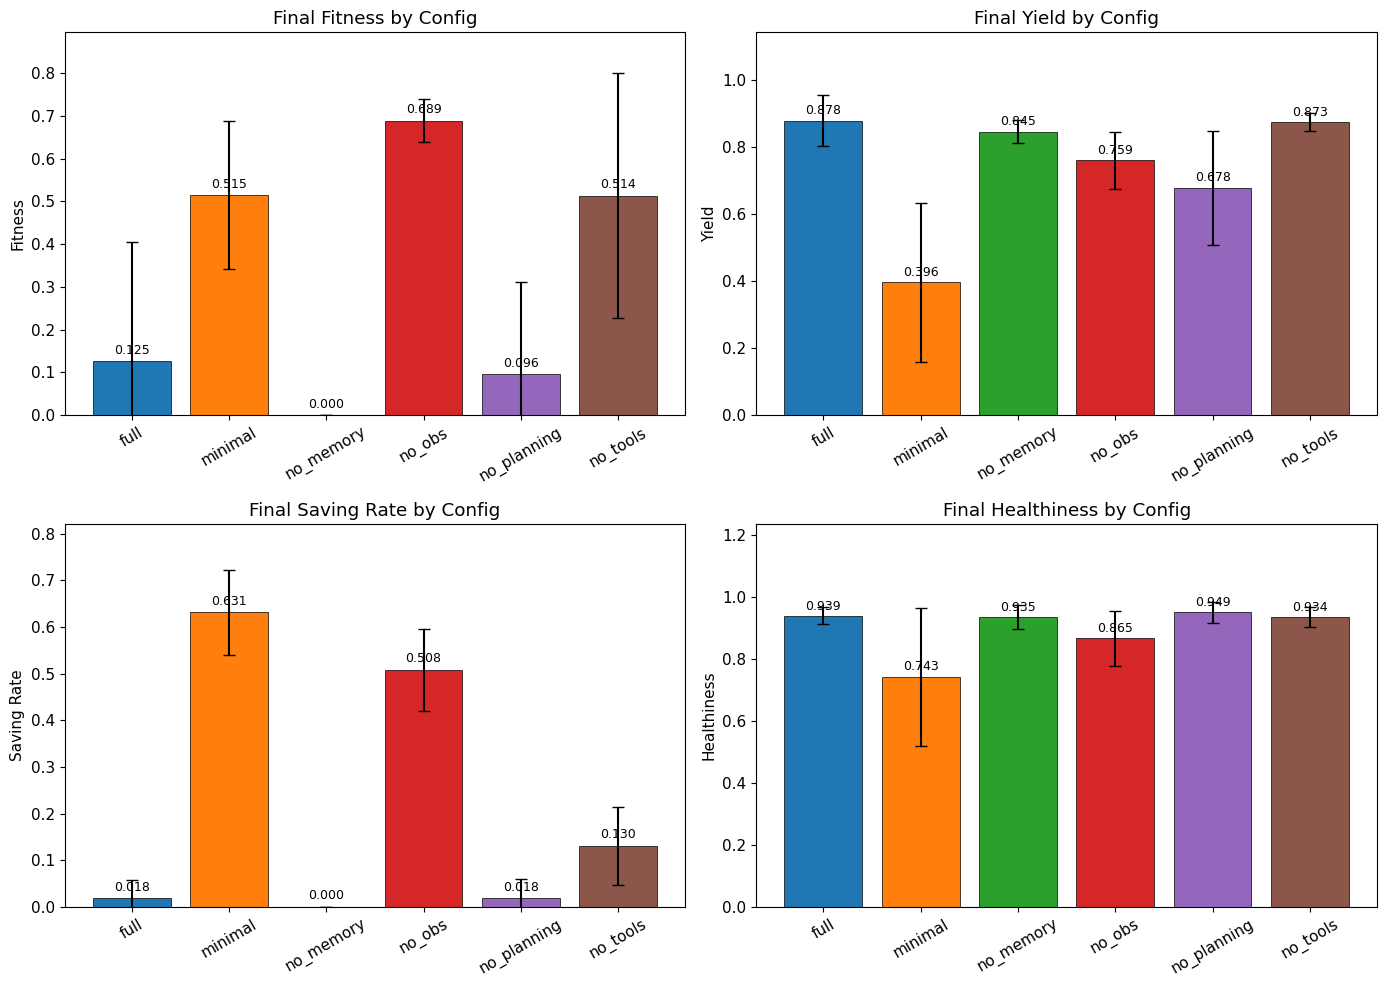

Saved ablation_bars.png


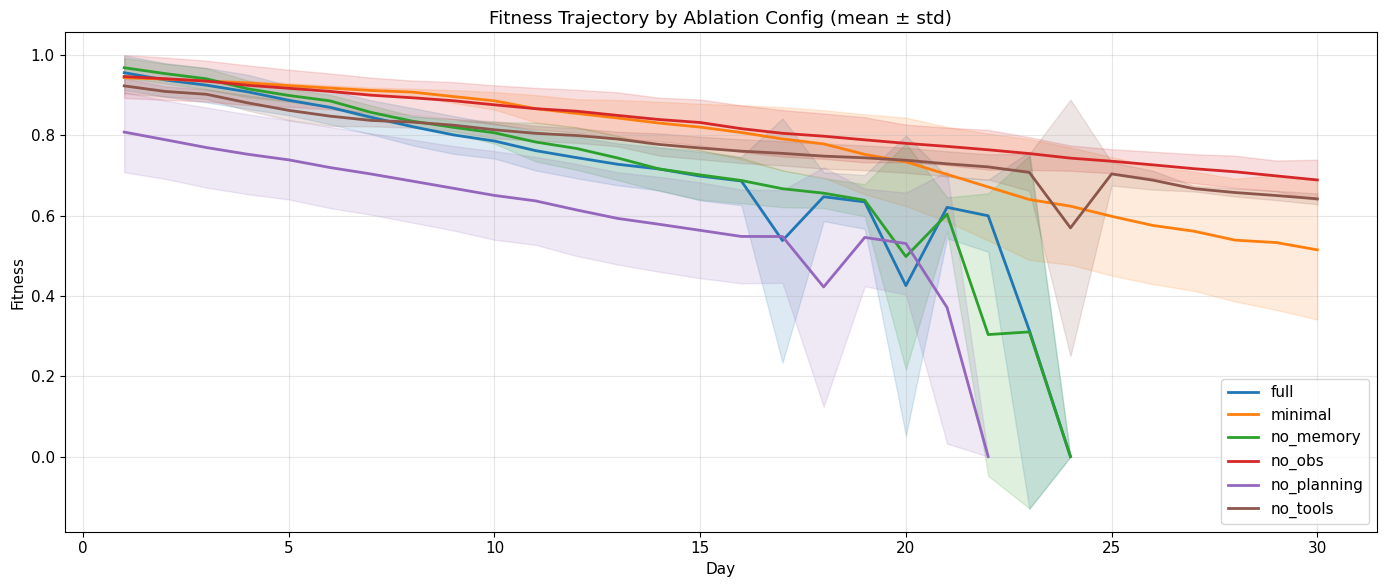

Saved ablation_trajectories.png


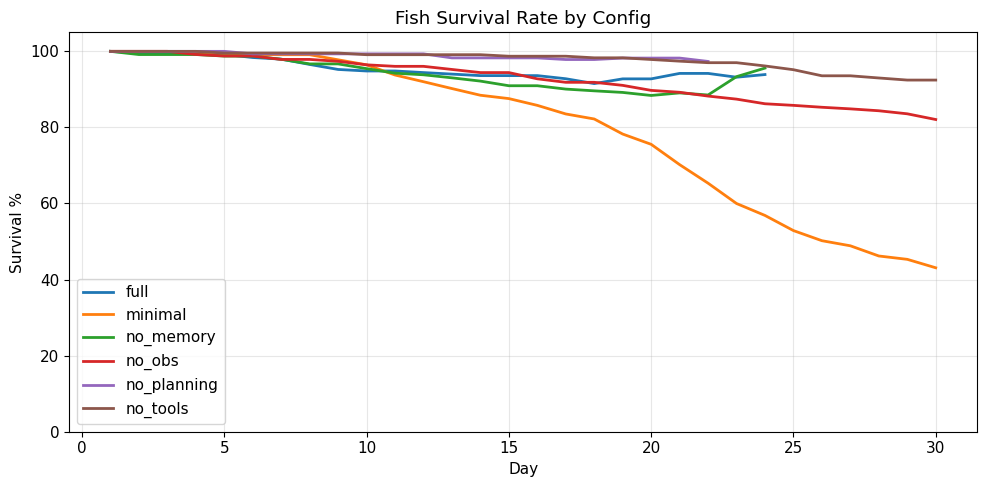

Saved ablation_survival.png


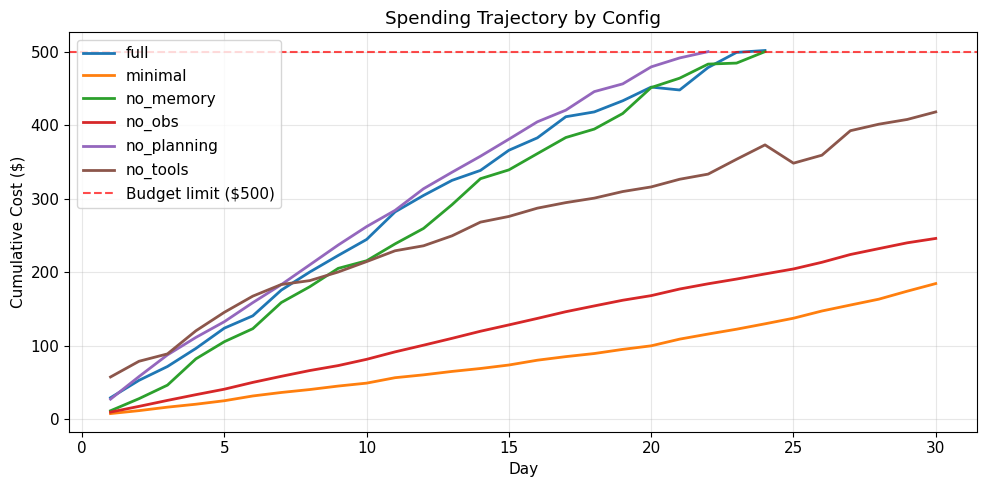

Saved ablation_cost.png


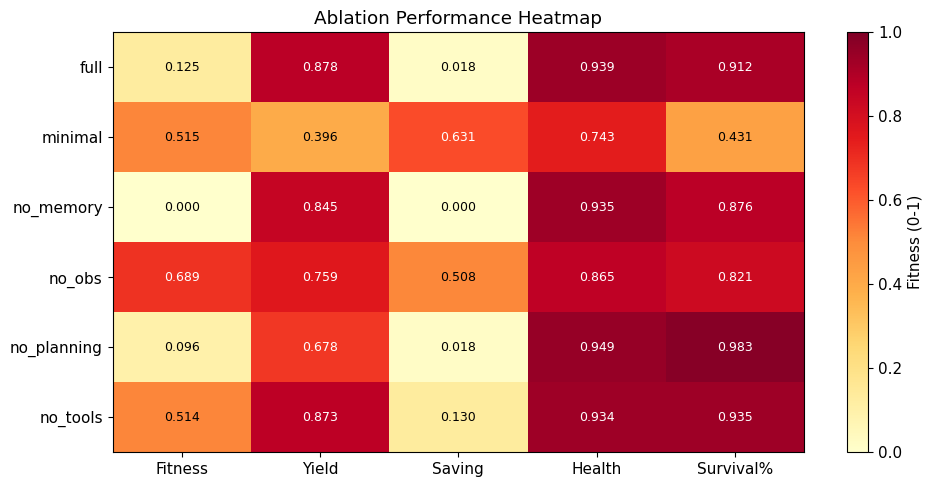

Saved ablation_heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 All plots downloaded.

ABLATION SUMMARY
            fitness           yield saving_ratio healthiness survival_pct    cost
               mean     std    mean         mean        mean         mean    mean
config                                                                           
full         0.1254  0.2804  0.8776       0.0180      0.9386        91.18  492.04
minimal      0.5151  0.1736  0.3959       0.6310      0.7425        43.10  184.48
no_memory    0.0000  0.0000  0.8449       0.0000      0.9347        87.56  501.71
no_obs       0.6890  0.0503  0.7592       0.5080      0.8653        82.08  246.01
no_planning  0.0959  0.2144  0.6775       0.0182      0.9493        98.28  491.49
no_tools     0.5136  0.2874  0.8735       0.1304      0.9344        93.52  435.20

  RANKING (by mean fitness):
    1. no_obs — 0.6890
    2. minimal — 0.5151
    3. no_tools — 0.5136
    4. full — 0.1254
    5. no_planning — 0.0959
    6. no_memory — 0.0000


In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

matplotlib.rcParams.update({'font.size': 11})

CSV_PATH = "/content/AquaLLM/logs/llm_results.csv"
PLOTS_DIR = "/content/AquaLLM/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("No results CSV found. Run Cell 13 first.")
else:
    df = pd.read_csv(CSV_PATH)
    print("Loaded {} rows from {}".format(len(df), CSV_PATH))
    print("Configs found: {}".format(df["config"].unique().tolist()))
    print("Generations: {}".format(sorted(df["generation"].unique())))

    # ── Shared color map ──
    configs = sorted(df["config"].unique())
    cmap = plt.cm.tab10
    CONFIG_COLORS = {cfg: cmap(i) for i, cfg in enumerate(configs)}

    # ── Per-generation final fitness (last day of each gen) ──
    final = df.groupby(["config", "run", "generation"]).last().reset_index()

    # ── 1. Bar chart: Final metrics by config (2x2) ──
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, metric, label in [
        (0, "fitness", "Fitness"),
        (1, "yield", "Yield"),
        (2, "saving_ratio", "Saving Rate"),
        (3, "healthiness", "Healthiness"),
    ]:
        ax = axes[idx]
        means = [final[final["config"] == c][metric].astype(float).mean() for c in configs]
        stds = [final[final["config"] == c][metric].astype(float).std() for c in configs]

        colors = [CONFIG_COLORS[c] for c in configs]
        bars = ax.bar(configs, means, yerr=stds, capsize=4, color=colors, edgecolor="black", linewidth=0.5)
        ax.set_ylabel(label)
        ax.set_title("Final {} by Config".format(label))
        ax.set_ylim(0, max(means) * 1.3 if max(means) > 0 else 1)
        for bar, m in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    "{:.3f}".format(m), ha="center", va="bottom", fontsize=9)
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "ablation_bars.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ablation_bars.png")

    # ── 2. Line chart: Fitness over days by config ──
    fig, ax = plt.subplots(figsize=(14, 6))

    for cfg in configs:
        cfg_df = df[df["config"] == cfg]
        daily_mean = cfg_df.groupby("day")["fitness"].mean().astype(float)
        daily_std = cfg_df.groupby("day")["fitness"].std().astype(float).fillna(0)
        days = daily_mean.index
        ax.plot(days, daily_mean, label=cfg, color=CONFIG_COLORS[cfg], linewidth=2)
        ax.fill_between(days, daily_mean - daily_std, daily_mean + daily_std,
                        alpha=0.15, color=CONFIG_COLORS[cfg])

    ax.set_xlabel("Day")
    ax.set_ylabel("Fitness")
    ax.set_title("Fitness Trajectory by Ablation Config (mean ± std)")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "ablation_trajectories.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ablation_trajectories.png")

    # ── 3. Survival rate comparison ──
    fig, ax = plt.subplots(figsize=(10, 5))
    for cfg in configs:
        cfg_df = df[df["config"] == cfg]
        daily_surv = cfg_df.groupby("day")["survival_pct"].mean().astype(float)
        ax.plot(daily_surv.index, daily_surv, label=cfg, color=CONFIG_COLORS[cfg], linewidth=2)

    ax.set_xlabel("Day")
    ax.set_ylabel("Survival %")
    ax.set_title("Fish Survival Rate by Config")
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "ablation_survival.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ablation_survival.png")

    # ── 4. Cost efficiency ──
    fig, ax = plt.subplots(figsize=(10, 5))
    for cfg in configs:
        cfg_df = df[df["config"] == cfg]
        daily_cost = cfg_df.groupby("day")["cost"].mean().astype(float)
        ax.plot(daily_cost.index, daily_cost, label=cfg, color=CONFIG_COLORS[cfg], linewidth=2)

    ax.axhline(y=500, color="red", linestyle="--", alpha=0.7, label="Budget limit ($500)")
    ax.set_xlabel("Day")
    ax.set_ylabel("Cumulative Cost ($)")
    ax.set_title("Spending Trajectory by Config")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "ablation_cost.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ablation_cost.png")

    # ── 5. Heatmap: Component contribution ──
    fig, ax = plt.subplots(figsize=(10, 5))
    components = ["fitness", "yield", "saving_ratio", "healthiness", "survival_pct"]
    comp_labels = ["Fitness", "Yield", "Saving", "Health", "Survival%"]

    matrix = []
    for cfg in configs:
        row = []
        for comp in components:
            val = final[final["config"] == cfg][comp].astype(float).mean()
            if comp == "survival_pct":
                val /= 100  # Normalize to 0-1
            row.append(val)
        matrix.append(row)

    matrix = np.array(matrix)
    im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(comp_labels)))
    ax.set_xticklabels(comp_labels)
    ax.set_yticks(range(len(configs)))
    ax.set_yticklabels(configs)
    for i in range(len(configs)):
        for j in range(len(comp_labels)):
            ax.text(j, i, "{:.3f}".format(matrix[i, j]),
                    ha="center", va="center", fontsize=9,
                    color="white" if matrix[i, j] > 0.6 else "black")
    plt.colorbar(im, ax=ax, label="Fitness (0-1)")
    ax.set_title("Ablation Performance Heatmap")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "ablation_heatmap.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved ablation_heatmap.png")

    # ── Download all plots ──
    from google.colab import files
    for fname in [
        "ablation_bars.png",
        "ablation_trajectories.png",
        "ablation_survival.png",
        "ablation_cost.png",
        "ablation_heatmap.png",
    ]:
        path = os.path.join(PLOTS_DIR, fname)
        if os.path.exists(path):
            files.download(path)
    print("\n📥 All plots downloaded.")

    # ── 6. Summary table ──
    print("\n" + "=" * 80)
    print("ABLATION SUMMARY")
    print("=" * 80)
    summary = final.groupby("config").agg({
        "fitness": ["mean", "std"],
        "yield": "mean",
        "saving_ratio": "mean",
        "healthiness": "mean",
        "survival_pct": "mean",
        "cost": "mean",
    }).round(4)
    print(summary.to_string())

    # ── Rank configs ──
    print("\n  RANKING (by mean fitness):")
    ranking = final.groupby("config")["fitness"].mean().astype(float).sort_values(ascending=False)
    for rank, (cfg, fit) in enumerate(ranking.items(), 1):
        print("    {}. {} — {:.4f}".format(rank, cfg, fit))